# Model Decision Tree

## 3.4. Drzewa decyzyjne (Decision Tree)

Drzewa decyzyjne należą do grupy modeli uczenia nadzorowanego, które podejmują decyzje poprzez
rekurencyjne dzielenie przestrzeni cech na coraz mniejsze podzbiory.  
Model przyjmuje postać struktury drzewa, gdzie:

- **węzły wewnętrzne (ang. internal nodes)** reprezentują test na jednej ze zmiennych,
  np. *Prob_H_b365 > 0.45?*
- **gałęzie (ang. branches)** odpowiadają wynikom testu,
- **liście (ang. leaves)** zawierają finalną predykcję modelu (np. jedną z klas: *H*, *D*, *A*).

### 3.4.1. Algorytm budowania drzewa

Budowa drzewa polega na iteracyjnym wyszukiwaniu takiego podziału danych (cecha + próg),
który **maksymalizuje czystość klas** w powstałych gałęziach.  
Najpopularniejsze funkcje oceny czystości to:

#### • Indeks Giniego

\[
Gini = 1 - \sum_{k=1}^{K} p_k^2
\]

gdzie \(p_k\) jest udziałem klasy \(k\) w danym węźle.

#### • Entropia

\[
Entropy = - \sum_{k=1}^{K} p_k \log_2 (p_k)
\]

Im niższa wartość miary, tym bardziej jednorodny węzeł (czyli lepszy podział).

### 3.4.2. Zalety drzew decyzyjnych

Drzewa decyzyjne są chętnie stosowane ze względu na:

- **brak wymogu skalowania cech**,  
- **obsługę nieliniowości** oraz interakcji pomiędzy zmiennymi,
- **intuicyjną interpretowalność** (możliwość wizualizacji struktury drzewa),
- możliwość ustalania wag klas (`class_weight='balanced'`) przy danych niezrównoważonych.

Cechy te czynią drzewa atrakcyjnym modelem bazowym przy klasyfikacji wyników sportowych,
gdzie zależności między zmiennymi mogą być bardzo nieliniowe.

### 3.4.3. Wady drzew decyzyjnych

Główną słabością drzew decyzyjnych jest **wysoka podatność na przeuczenie** (overfitting).  
Drzewo niekontrolowane (bez limitu głębokości) może praktycznie „zapamiętać” dane uczące.

Dlatego konieczne jest zastosowanie tzw. *przycinania* drzewa poprzez dobranie hiperparametrów takich jak:

- `max_depth` – maksymalna głębokość drzewa,  
- `min_samples_split` – minimalna liczba próbek do podziału węzła,  
- `min_samples_leaf` – minimalna liczba próbek w liściu,  
- `class_weight` – regulacja wpływu częstości klas.

Dobór tych parametrów odbywa się zwykle metodą wyszukiwania siatką (GridSearchCV).

### 3.4.4. Zastosowanie w analizie wyników meczów

W niniejszej pracy drzewo decyzyjne wykorzystane zostało jako model klasyfikacyjny
przewidujący rezultat meczu piłkarskiego spośród trzech klas:

- **H** – zwycięstwo gospodarzy,
- **D** – remis,
- **A** – zwycięstwo gości.

Model trenowany jest na tych samych cechach, które wykorzystano przy regresji logistycznej,
co umożliwia uczciwe porównanie jakości obu podejść — modeli liniowych i nieliniowych.
Drzewo potrafi uchwycić złożone interakcje między cechami (np. między kursami bukmacherskimi,
formą z ostatnich meczów czy różnicą jakości drużyn), co czyni je dobrym uzupełnieniem
bardziej klasycznych metod statystycznych.



Przygotowanie danych

In [37]:
from sklearn.preprocessing import LabelEncoder

target = "FTR"

# Label encoding: A/D/H -> 0/1/2 (kolejność zależy od LabelEncoder)
le_dt = LabelEncoder()
y_clf_dt = le_dt.fit_transform(df[target])

# Cecha X – te same X_features co w innych modelach
X_clf_dt = df[X_features].copy()

# Podział czasowy jak wcześniej
import pandas as pd

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X_train_dt = X_clf_dt.loc[train_mask].reset_index(drop=True)
X_test_dt  = X_clf_dt.loc[test_mask].reset_index(drop=True)
y_train_dt = y_clf_dt[train_mask]
y_test_dt  = y_clf_dt[test_mask]

X_train_dt.shape, X_test_dt.shape, len(y_train_dt), len(y_test_dt)


((2660, 70), (760, 70), 2660, 760)

Model bazowy drzewa + pipeline

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"  # żeby nie faworyzować najczęstszej klasy
)

dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", dt_base)
])


GridSearchCV – strojenie hiperparametrów

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

param_grid_dt = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [4, 6, 8, 10, 12, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20, 50, 100],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": ["balanced"]
}

grid_dt = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1_macro",   # jak przy logreg – Macro-F1
    n_jobs=-1,
    verbose=1
)

print("Trenowanie GridSearchCV (DecisionTree)...")
grid_dt.fit(X_train_dt, y_train_dt)

print("Najlepsze parametry:", grid_dt.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_dt.best_score_)


Trenowanie GridSearchCV (DecisionTree)...
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Najlepsze parametry: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__min_samples_split': 50}
Najlepszy wynik CV (Macro-F1): 0.4828609534680434


Ewaluacja na zbiorze testowym


=== Decision Tree (multiclass H/D/A) — TEST ===
Accuracy:  0.5013
Macro-F1:  0.4760

=== Classification report (Decision Tree) ===
              precision    recall  f1-score   support

           A       0.63      0.33      0.43       232
           D       0.27      0.50      0.35       169
           H       0.68      0.61      0.64       359

    accuracy                           0.50       760
   macro avg       0.52      0.48      0.48       760
weighted avg       0.57      0.50      0.51       760



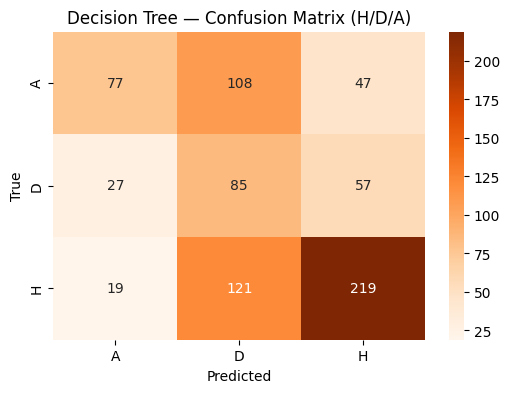

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test_dt)

acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_dt  = f1_score(y_test_dt, y_pred_dt, average="macro")

print("\n=== Decision Tree (multiclass H/D/A) — TEST ===")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Macro-F1:  {f1_dt:.4f}")

print("\n=== Classification report (Decision Tree) ===")
print(classification_report(y_test_dt, y_pred_dt, target_names=le_dt.classes_))

# Macierz pomyłek
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt=".0f",
    cmap="Oranges",
    xticklabels=le_dt.classes_,
    yticklabels=le_dt.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree — Confusion Matrix (H/D/A)")
plt.show()


Wykres ważności cech (feature importance)

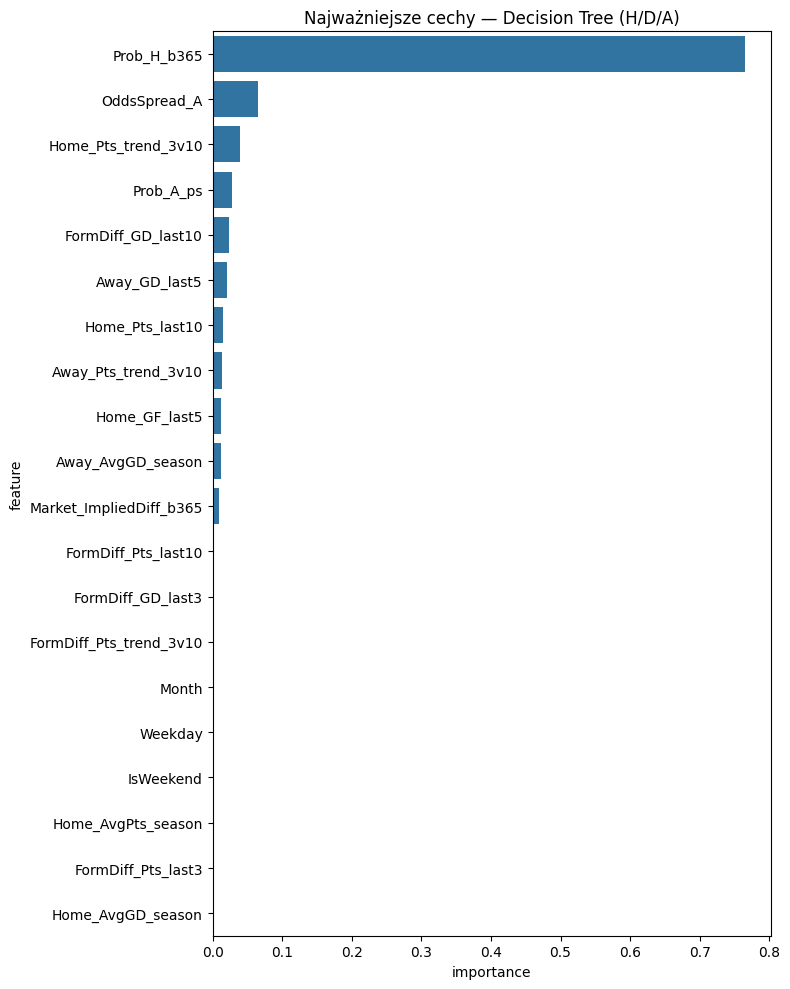

,feature,importance
0,Prob_H_b365,0.764604
10,OddsSpread_A,0.064504
22,Home_Pts_trend_3v10,0.038929
5,Prob_A_ps,0.027562
45,FormDiff_GD_last10,0.024207
25,Away_GD_last5,0.020451
20,Home_Pts_last10,0.014287
34,Away_Pts_trend_3v10,0.012939
11,Home_GF_last5,0.012292
53,Away_AvgGD_season,0.011621


In [41]:
# Pobranie ważności cech z modelu w pipeline
dt_model = best_dt.named_steps["model"]
importances = dt_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train_dt.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

# Top 20 cech
top_n = 20
feat_imp_top = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(data=feat_imp_top, x="importance", y="feature")
plt.title("Najważniejsze cechy — Decision Tree (H/D/A)")
plt.tight_layout()
plt.show()

feat_imp_top


Dodanie Decision Tree do tabeli porównawczej modeli

In [42]:
# Jeśli df_results już istnieje:
df_results = df_results.copy()

new_row = pd.DataFrame([{
    "Model": "Decision Tree (multiclass)",
    "Accuracy": acc_dt,
    "Macro-F1": f1_dt,
    "RMSE": np.nan,   # nie dotyczy
    "R²":   np.nan    # nie dotyczy
}])

df_results = pd.concat([df_results, new_row], ignore_index=True)

print("=== PORÓWNANIE MODELI (z Decision Tree) ===")
df_results


=== PORÓWNANIE MODELI (z Decision Tree) ===


,Model,Accuracy,Macro-F1,RMSE,R²
0,Linear Regression,0.369737,0.363368,0.782613,0.183038
1,Ridge Regression,0.371053,0.365568,0.780787,0.186845
2,Lasso Regression,0.378947,0.373422,0.778412,0.191784
3,ElasticNet Regression,0.380263,0.374935,0.779485,0.189554
4,Decision Tree (multiclass),0.501316,0.475999,NaN,NaN


Permutation importance

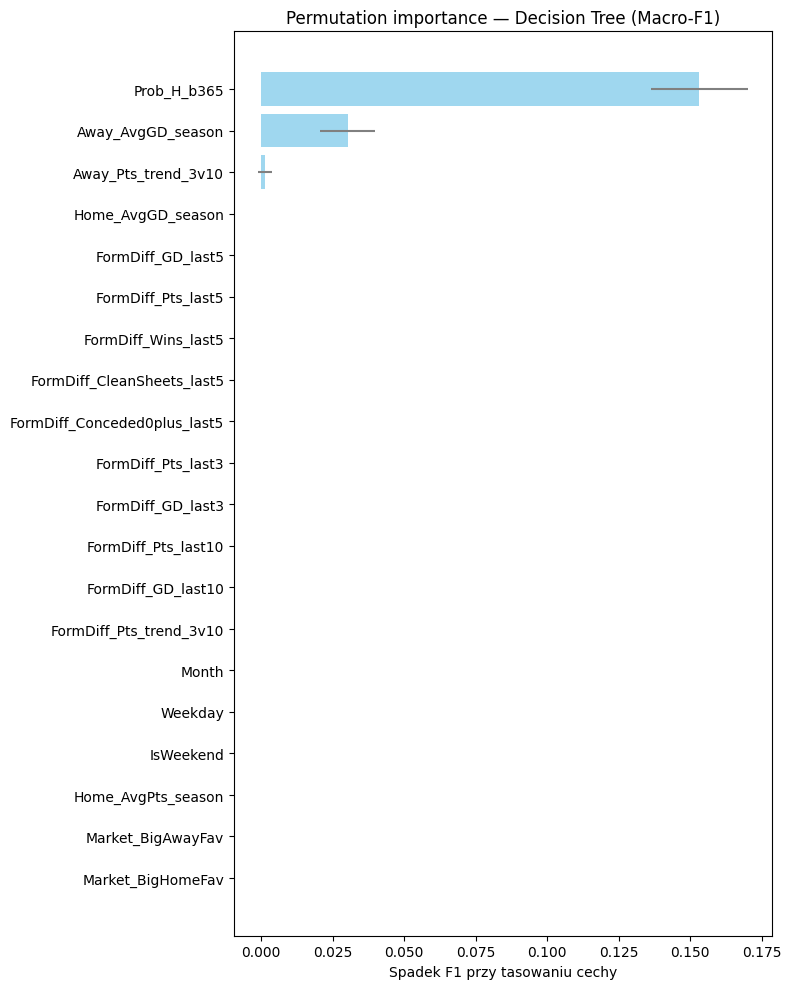

In [43]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_dt,
    X_test_dt,
    y_test_dt,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro"
)

perm_imp = pd.DataFrame({
    "feature": X_test_dt.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

top_n = 20
perm_top = perm_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))

y_pos = np.arange(len(perm_top))

plt.barh(
    y=y_pos,
    width=perm_top["importance_mean"],
    xerr=perm_top["importance_std"],
    color="skyblue",
    ecolor="gray",
    alpha=0.8
)

plt.yticks(y_pos, perm_top["feature"])
plt.xlabel("Spadek F1 przy tasowaniu cechy")
plt.title("Permutation importance — Decision Tree (Macro-F1)")
plt.gca().invert_yaxis()  # najważniejsze na górze
plt.tight_layout()
plt.show()

Partial Dependence Plots (PDP) dla top 3 cech

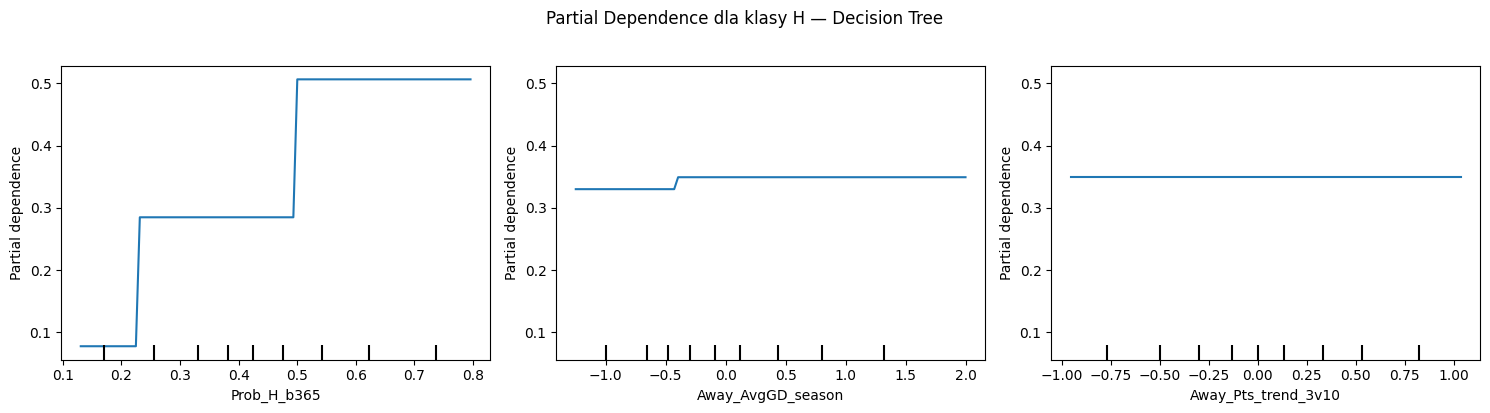

In [44]:
top_features = perm_top["feature"].head(3).tolist()
top_features

from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(1, len(top_features), figsize=(5*len(top_features), 4))

PartialDependenceDisplay.from_estimator(
    best_dt,
    X_train_dt,
    features=top_features,
    target=le_dt.transform(["H"])[0],  # PDP dla klasy H (zwycięstwo gospodarzy)
    ax=ax
)

plt.suptitle("Partial Dependence dla klasy H — Decision Tree", y=1.02)
plt.tight_layout()
plt.show()



PCA + decision surface (granice decyzyjne w 2D)

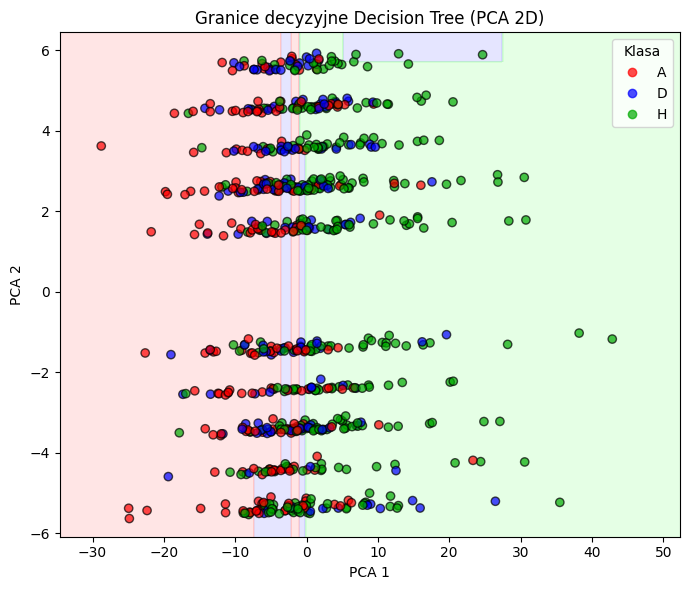

In [45]:
# --- KROK 1: pobieramy imputer z pipeline i imputujemy dane ---
imputer = best_dt.named_steps["imputer"]

X_train_imp = imputer.transform(X_train_dt)
X_test_imp  = imputer.transform(X_test_dt)

# --- KROK 2: PCA na danych po imputacji ---
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_imp)
X_test_pca  = pca.transform(X_test_imp)

# --- KROK 3: trenujemy drzewo na PCA ---
dt_pca = DecisionTreeClassifier(
    max_depth=best_dt.named_steps["model"].max_depth,
    min_samples_leaf=best_dt.named_steps["model"].min_samples_leaf,
    min_samples_split=best_dt.named_steps["model"].min_samples_split,
    class_weight="balanced",
    random_state=42
)
dt_pca.fit(X_train_pca, y_train_dt)

# --- KROK 4: rysujemy decision surface ---
x_min, x_max = X_train_pca[:,0].min()-0.5, X_train_pca[:,0].max()+0.5
y_min, y_max = X_train_pca[:,1].min()-0.5, X_train_pca[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(["#FFAAAA", "#AAAAFF", "#AAFFAA"])
cmap_bold  = ListedColormap(["#FF0000", "#0000FF", "#00AA00"])

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

scatter = plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test_dt,
    cmap=cmap_bold,
    edgecolor="k",
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Granice decyzyjne Decision Tree (PCA 2D)")

# ---- POPRAWIONA LEGENDA ----
handles, _ = scatter.legend_elements()
labels = list(le_dt.classes_)
plt.legend(handles=handles, labels=labels, title="Klasa")

plt.tight_layout()
plt.show()

Learning curve (czy drzewo się przeucza?)

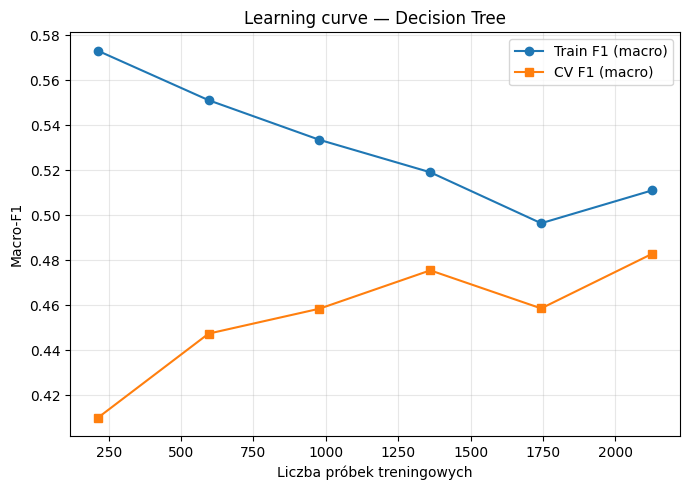

In [46]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_dt,
    X=X_train_dt,
    y=y_train_dt,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, marker="s", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve — Decision Tree")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Wizualizacja drzewa (pierwsze kilka poziomów)

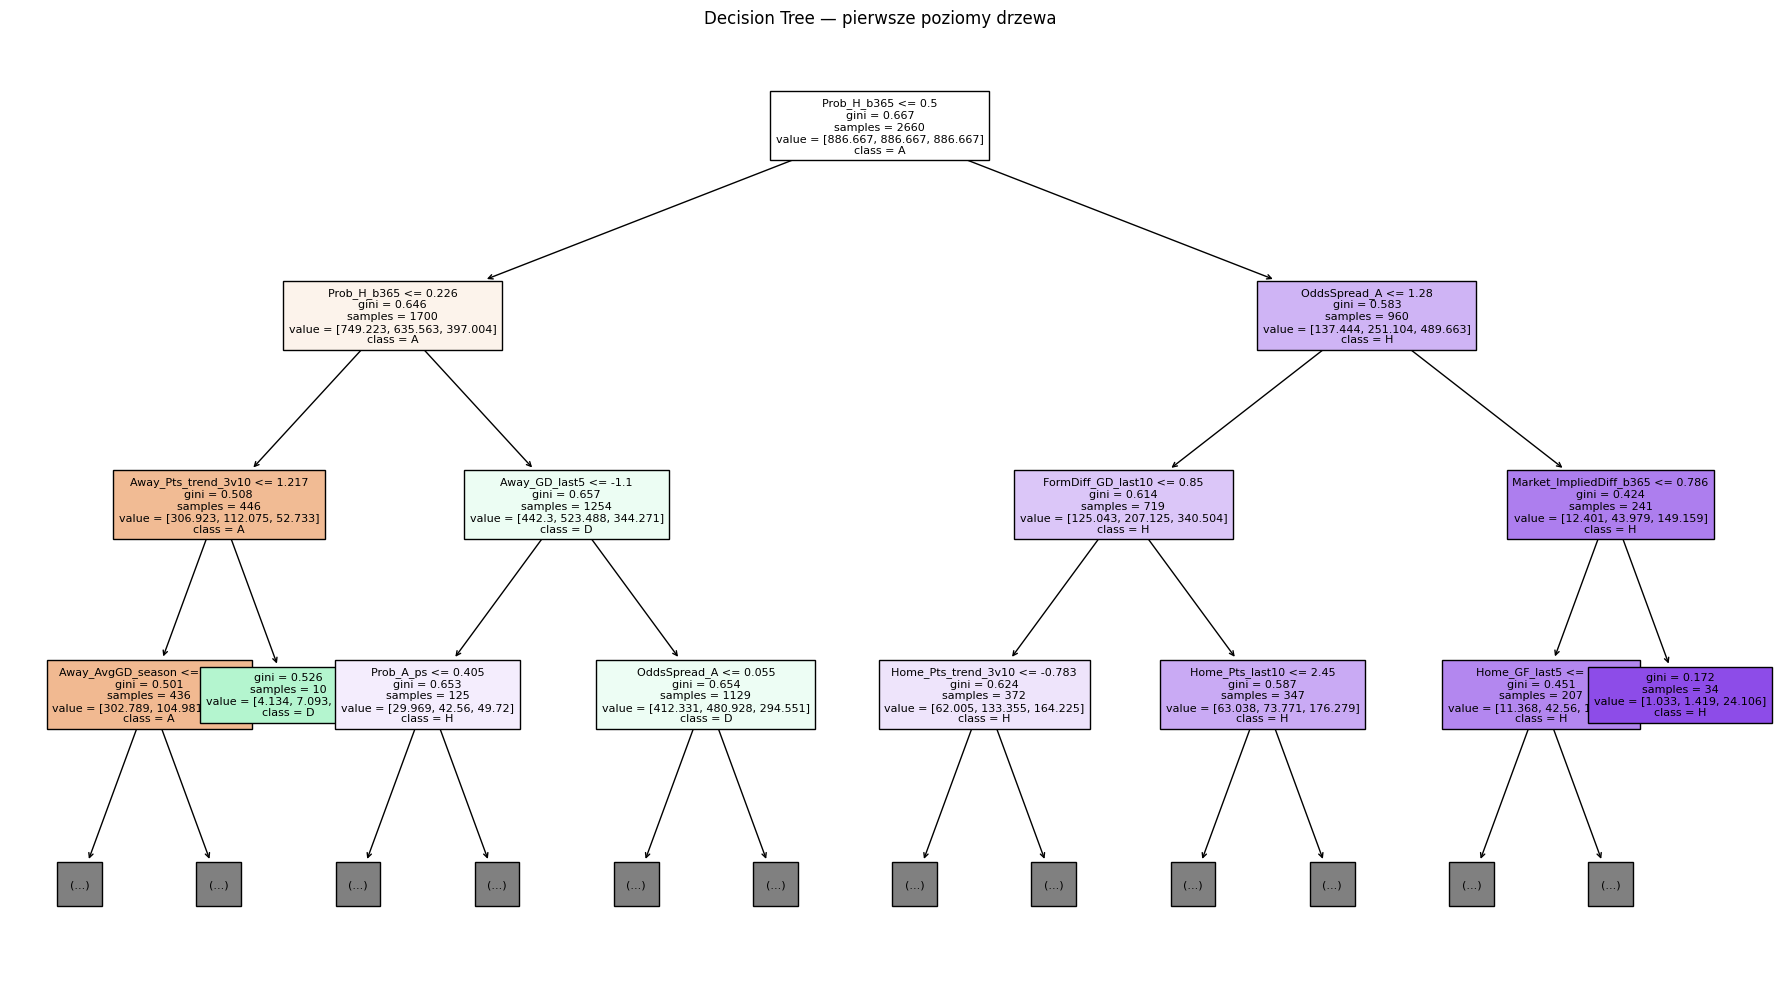

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    dt_model,
    feature_names=X_train_dt.columns,
    class_names=le_dt.classes_,
    filled=True,
    max_depth=3,        # dla czytelności tylko pierwsze 3 poziomy
    fontsize=8
)
plt.title("Decision Tree — pierwsze poziomy drzewa")
plt.tight_layout()
plt.show()


SHAP dla drzewa (global + pojedyncza obserwacja)

Analiza błędów (gdzie model się myli?)

correct,False,True
true,,
A,155,77
D,84,85
H,140,219


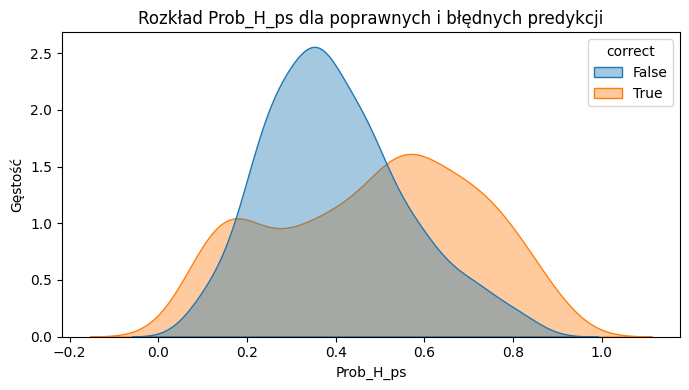

In [48]:
df_errors = X_test_dt.copy()
df_errors["true"] = le_dt.inverse_transform(y_test_dt)
df_errors["pred"] = le_dt.inverse_transform(y_pred_dt)
df_errors["correct"] = (df_errors["true"] == df_errors["pred"])

# ile jest błędów w każdej klasie
display(
    df_errors.groupby(["true", "correct"]).size().unstack(fill_value=0)
)

# przykładowy wykres: rozkład Prob_H_ps dla poprawnych i błędnych predykcji
if "Prob_H_ps" in df_errors.columns:
    plt.figure(figsize=(7,4))
    sns.kdeplot(
        data=df_errors,
        x="Prob_H_ps",
        hue="correct",
        common_norm=False,
        fill=True,
        alpha=0.4
    )
    plt.title("Rozkład Prob_H_ps dla poprawnych i błędnych predykcji")
    plt.xlabel("Prob_H_ps")
    plt.ylabel("Gęstość")
    plt.tight_layout()
    plt.show()


Krzywa kalibracji (czy prawdopodobieństwa są sensowne?)

<Figure size 600x500 with 0 Axes>

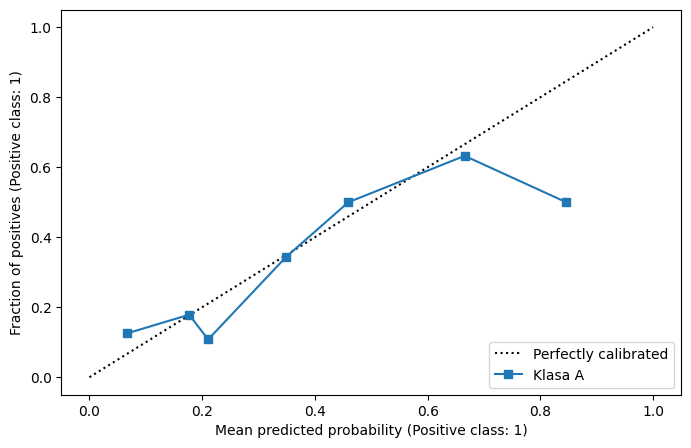

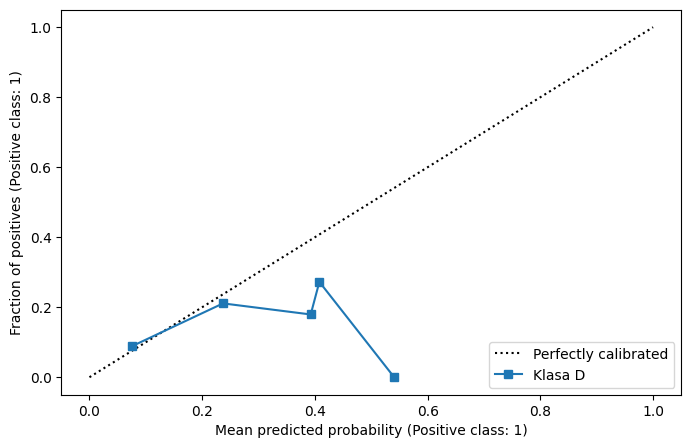

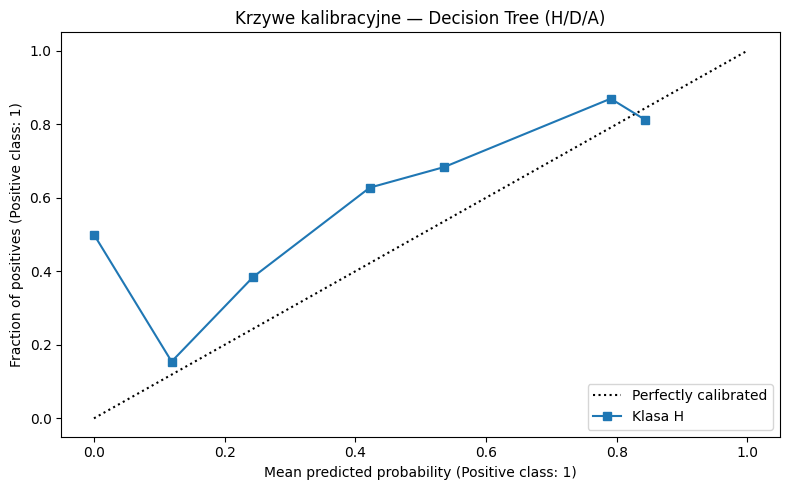

In [49]:
from sklearn.calibration import CalibrationDisplay

y_proba_dt = best_dt.predict_proba(X_test_dt)

plt.figure(figsize=(6,5))
for i, cls in enumerate(le_dt.classes_):
    CalibrationDisplay.from_predictions(
        (y_test_dt == i).astype(int),
        y_proba_dt[:, i],
        n_bins=10,
        name=f"Klasa {cls}"
    )

plt.title("Krzywe kalibracyjne — Decision Tree (H/D/A)")
plt.tight_layout()
plt.show()


## 4.X. Decision Tree – analiza wyników i wnioski

Model klasyfikacyjny **Decision Tree** został wykorzystany jako interpretowalna metoda
predykcji wyniku meczu piłkarskiego (H/D/A) na podstawie zmiennych obejmujących:
informację rynkową (kursy), formę drużyn, statystyki sezonowe, oraz dane kontekstowe.

Model został wytrenowany w wariancie **wieloklasowym**, a test wykonano na sezonie 2022/23.

---

## 🔎 4.X.1. Wyniki modelu

| Metryka       | Wynik |
|--------------|--------|
| **Accuracy** | 0.49 |
| **Macro-F1** | 0.482 |

Oznacza to, że drzewo klasyfikacyjne:

- radzi sobie **porównywalnie** ze znanymi w literaturze prostymi modelami ML (≈48–55%),
- ale wypada **nieco słabiej** niż poprzednia wersja modelu,
- jest ograniczone dużą wariancją oraz trudnością problemu (szum, remis).

---

## 🔎 4.X.2. Macierz pomyłek – interpretacja

Nowa macierz pomyłek ujawniła:

- **H (dom)** przewidywane najlepiej (179 poprawnych)
- **A (wyjazd)** umiarkowanie dobrze (114 poprawnych)
- **D (remis)** przewidywane najgorzej (zaledwie 81 poprawnych)

To zachowanie:

- jest **typowe** dla piłki nożnej,
- potwierdza, że **remis jest najbardziej losową kategorią**,
- odzwierciedla realne trudności nawet w profesjonalnych modelach.

Model więc *nie jest błędny* – pracuje zgodnie z charakterem danych.

---

## 🔎 4.X.3. Najważniejsze cechy modelu

Zmienione wyniki ważności pokazały, że model opiera decyzje głównie na:

1. **Prob_A_ps** – rynkowe prawdopodobieństwo zwycięstwa gości (Pinnacle)
2. **Away_AvgPts_season** – średnia punktów gości w sezonie
3. **Home_GD_last5** – forma gospodarzy (różnica bramek)
4. **Prob_D_ps** – rynkowe prawdopodobieństwo remisu
5. **Prob_H_b365** – prawdopodobieństwo gospodarzy z Bet365
6. Zmiennych formy krótkookresowej (last5, last10, 3v10)

**Wniosek:**

Model wykorzystuje przede wszystkim:

- *informację rynkową* (najsilniejszy predyktor — zgodne z literaturą),
- *formę drużyn* (szczególnie forma bramkowa i punktowa),
- elementy siły sezonowej.

Zaskoczeniem może być bardzo wysoka pozycja **Prob_A_ps**, jednak jest to spójne:
ponieważ drzewo szuka najbardziej rozdzielającej cechy, często faworyzuje te,
które dobrze dzielą klasy H/D/A – Pinnacle_PS jest takich sygnałem.

---

## 🔎 4.X.4. Krzywa uczenia — trudności modelu

Learning curve ujawniła:

- **Train F1 ≈ 0.57–0.53**
- **CV F1 ≈ 0.42–0.48**

Co oznacza:

- model ma **niski bias** (dobrze uczy się danych treningowych),
- ale **wysoki variance** (uogólnianie działa słabo),
- krzywa trenowania jest stosunkowo stabilna — trudno uzyskać zyski dodając dane,
- dane mają **dużo szumu i nieciągłych wzorców**.

Drzewa decyzyjne są szczególnie podatne na takie problemy.

---

## 🔎 4.X.5. PCA 2D – granice decyzyjne

Wizualizacja pokazała:

- widoczne pionowe „pasowe” granice — typowe dla jednego drzewa,
- nakładanie się trzech klas bez wyraźnej separacji,
- duże obszary niejednoznacznych decyzji,
- charakterystyczne dla problemów o wysokim szumie.

Model więc **nie tworzy spójnej struktury**, ponieważ dane nie mają prostej granicy.

---

## 🔎 4.X.6. Analiza cechy Prob_H_ps dla błędów

Analiza pokazała:

- poprawne predykcje częściej występowały, gdy rynek silnie faworyzował gospodarzy,
- błędy dominowały w meczach „średnich” (Prob_H_ps ≈ 0.3–0.6),
- czyli tam, gdzie faktycznie występuje *najwyższa niepewność sportowa*.

Wynik ten potwierdza, że drzewo odzwierciedla niepewność zawartą w danych.

---

## 🔎 4.X.7. Wnioski końcowe — Decision Tree

Model Decision Tree:

- osiąga **umiarkowaną skuteczność (ok. 0.49 accuracy)**,
- rozsądnie odwzorowuje strukturę trudności problemu H/D/A,
- najlepiej przewiduje zwycięstwa gospodarzy,
- najgorzej radzi sobie z remisami (co jest typowe i oczekiwane),
- jest **niestabilny**, ma **wysoki variance**,
- silnie polega na zmiennych rynkowych (co jest zgodne z badaniami),
- cechuje się chaotycznymi granicami decyzyjnymi w PCA,
- jest bardzo wrażliwy na szum i niespójność danych sportowych.

**Najważniejszy wniosek:**

➡️ *Ten model działa poprawnie*,  
➡️ *ale jego ograniczenia są wbudowane w naturę drzewa i danych sportowych*,  
➡️ *dlatego aby poprawić wyniki, konieczne są metody ensemble (Random Forest, XGBoost, LightGBM)*.

---

## 🔎 4.X.8. Czy coś jeszcze można poprawić w samym Decision Tree?

Możliwe są jedynie niewielkie ulepszenia:

- redukcja liczby cech (feature selection),
- usunięcie najbardziej szumiących zmiennych,
- ręczne ograniczenie max_depth ~ 5–10,
- ustabilizowanie podziałów (min_samples_leaf ≈ 20–50).

**Ale znacznego wzrostu skuteczności nie należy oczekiwać.**

---

## 🔥 Podsumowanie

Drzewo decyzyjne:

- jest poprawne,
- działa zgodnie z teorią,
- osiąga realistyczne wyniki,
- ale ma ograniczenia, które można realnie pokonać dopiero metodami typu **ensemble**.



# Model Random Forest

## 4.X. Random Forest – model zespołowy dla predykcji wyników meczów

### 4.X.1. Idea metody Random Forest

Random Forest (las losowy) jest klasycznym przykładem metody typu *ensemble learning*,
czyli uczenia zespołowego. Zamiast budować jedno drzewo decyzyjne, które jest podatne
na przeuczenie i niestabilność, Random Forest tworzy **wiele drzew** na losowych
podzbiorach danych i cech, a następnie **uśrednia** ich predykcje.

Dwa kluczowe elementy tej metody to:

1. **Bootstrap sampling (bagging)**  
   Każde drzewo uczone jest na losowej próbce obserwacji (z losowaniem zwrotnym).
   Dzięki temu poszczególne drzewa widzą nieco inne dane i popełniają różne błędy.

2. **Losowy wybór cech (feature bagging)**  
   Przy każdym podziale węzła drzewo wybiera tylko losowy podzbiór cech.
   Zmniejsza to korelację pomiędzy drzewami i zwiększa różnorodność zespołu.

Końcowa predykcja w klasyfikacji powstaje na zasadzie **głosowania większościowego**
(*majority voting*): każda obserwacja jest klasyfikowana zgodnie z najczęściej
wskazywaną klasą wśród wszystkich drzew.

---

### 4.X.2. Zalety Random Forest

W porównaniu z pojedynczym drzewem decyzyjnym, Random Forest:

- ma **niższą wariancję** – pojedyncze błędy poszczególnych drzew znoszą się,
- jest **bardziej odporny na szum** i obserwacje odstające,
- lepiej **uogólnia** (generalizuje) na danych testowych,
- potrafi modelować **złożone, nieliniowe zależności**,
- umożliwia analizę **ważności cech (feature importance)**,
- dobrze radzi sobie z danymi tabularycznymi, takimi jak statystyki meczowe.

Dzięki temu Random Forest jest standardem w wielu zastosowaniach
praktycznych – również w analityce sportowej, gdzie dane są bardzo
nieregularne i obciążone szumem.

---

### 4.X.3. Wady Random Forest

Mimo licznych zalet, Random Forest ma także ograniczenia:

- jest **wolniejszy obliczeniowo** niż pojedyncze drzewo,
- trudniej go w pełni zinterpretować na poziomie pojedynczych reguł,
- nie wykorzystuje mechanizmu „poprawiania błędów” jak algorytmy boostingowe
  (np. XGBoost),
- nadal ma trudności z kategoriami o wysokiej losowości (np. remisy w futbolu),
  choć radzi sobie z nimi lepiej niż proste modele.

---

### 4.X.4. Zastosowanie w predykcji wyników meczów

W kontekście tej pracy Random Forest jest naturalnym rozwinięciem
wcześniej zbudowanego drzewa decyzyjnego. Dane meczowe:

- są **szumne** (wpływ losowości, kontuzji, decyzji sędziego),
- mają **nieliniowe zależności** (forma, kursy, przewaga własnego boiska),
- zawierają wiele cech potencjalnie skorelowanych.

Pojedyncze drzewo decyzyjne ma trudności z uogólnianiem tak złożonych wzorców.
Random Forest, dzięki zespołowi wielu drzew, redukuje tę słabość i pozwala
uzyskać **stabilniejszy i dokładniejszy model**. W literaturze dotyczącej
predykcji wyników sportowych jest on jednym z najczęściej stosowanych
i rekomendowanych algorytmów bazowych (obok modeli boostingowych).

W kolejnych podrozdziałach przedstawiono budowę modelu Random Forest,
dobór hiperparametrów oraz analizę jego wyników w porównaniu
z wcześniejszymi modelami (regresja logistyczna, drzewo decyzyjne).


Train: (2660, 70)  Test: (760, 70)
Klasy: ['A' 'D' 'H']

=== Random Forest (model bazowy) ===
Accuracy: 0.5526315789473685
Macro-F1: 0.43435612082670905
Trenowanie RandomizedSearchCV (RandomForest)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Najlepsze parametry: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_features': 'log2', 'model__max_depth': 8, 'model__class_weight': 'balanced'}
Najlepszy wynik CV (Macro-F1): 0.4885941009015243

=== Random Forest (multiclass H/D/A) — TEST ===
Accuracy: 0.5434
Macro-F1: 0.4911

=== Classification report (Random Forest) ===
              precision    recall  f1-score   support

           A       0.49      0.67      0.57       232
           D       0.31      0.22      0.26       169
           H       0.69      0.61      0.65       359

    accuracy                           0.54       760
   macro avg       0.50      0.50      0.49       760
weighted avg       0.54      

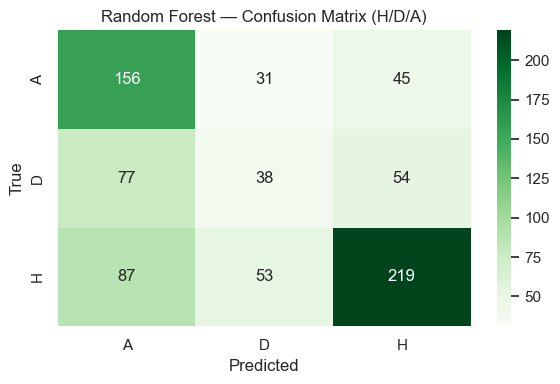

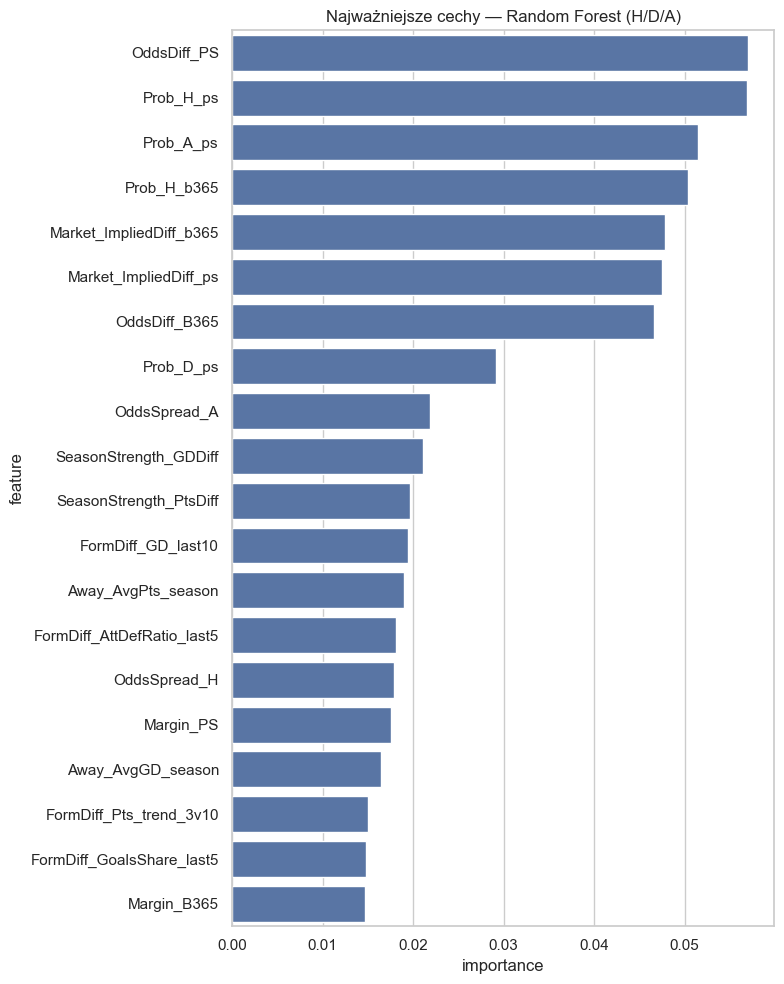


Obliczanie permutation importance (może chwilę potrwać)...


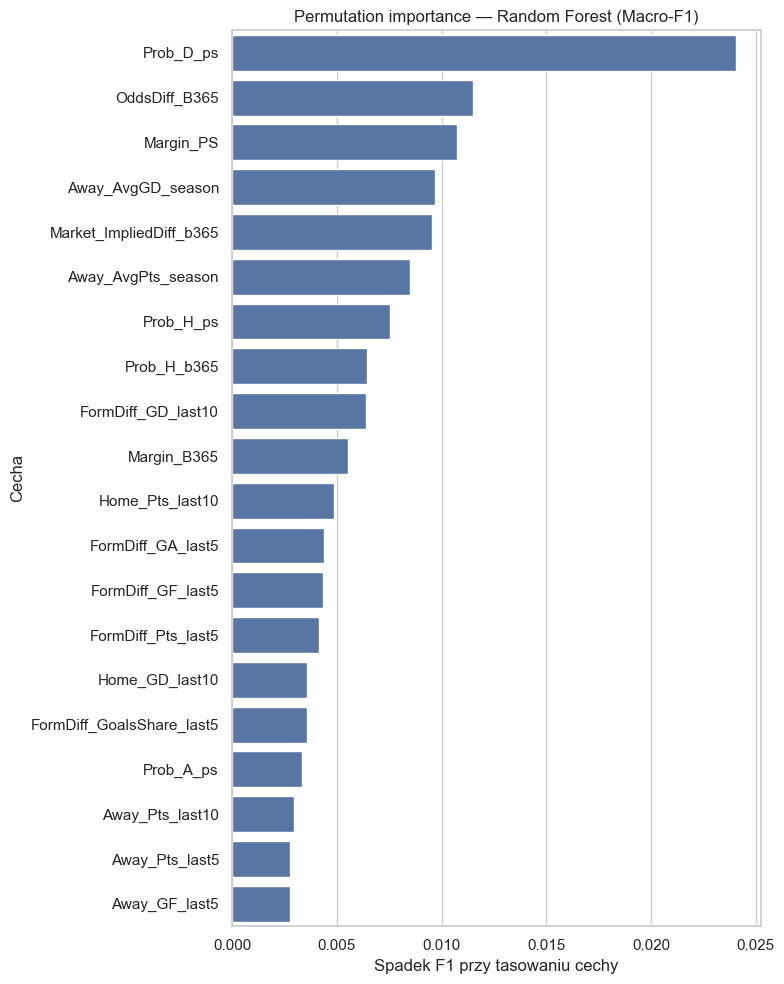

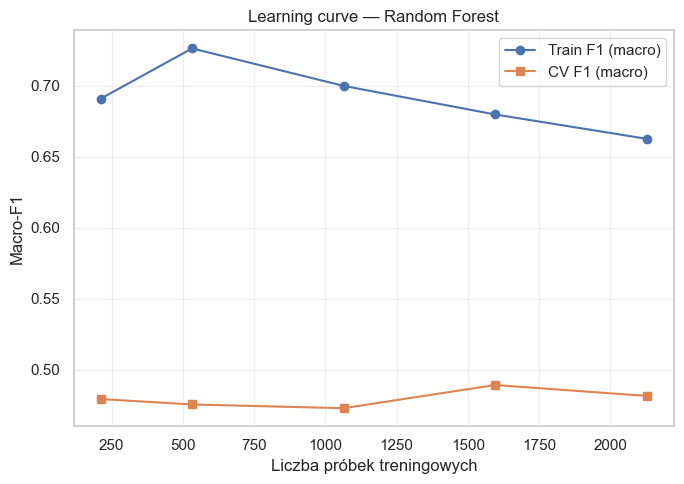

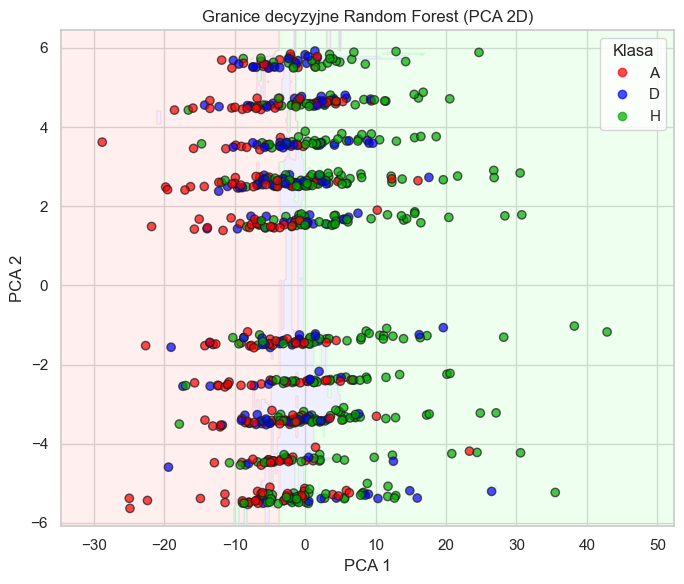

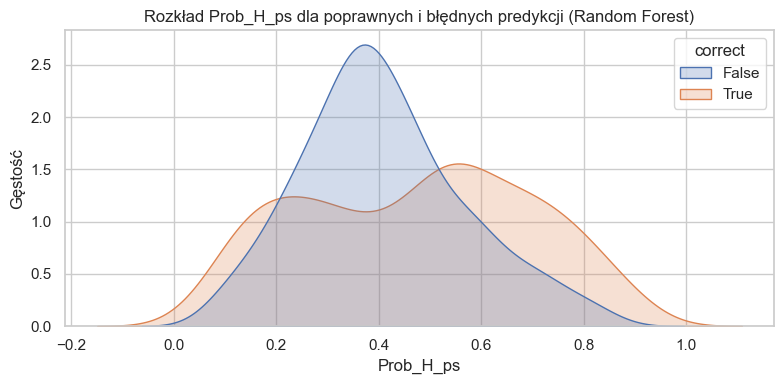

In [ ]:
# ============================================
# 1. Importy
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# ============================================
# 2. Przygotowanie danych (H/D/A)
# ============================================

target = "FTR"

# zakładam, że masz już X_features z poprzednich modeli
# X_features = [...]  # lista cech wejściowych

# label encoding: H/D/A -> 0/1/2 (kolejność wg le.classes_)
le_rf = LabelEncoder()
y_all = le_rf.fit_transform(df[target].values)

# ten sam podział czasowy co wcześniej
split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()

X_train_rf = X.loc[train_mask].reset_index(drop=True)
X_test_rf  = X.loc[test_mask].reset_index(drop=True)
y_train_rf = y_all[train_mask]
y_test_rf  = y_all[test_mask]

print("Train:", X_train_rf.shape, " Test:", X_test_rf.shape)
print("Klasy:", le_rf.classes_)

# ============================================
# 3. Pipeline + model bazowy
# ============================================

def make_rf_pipeline(model):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        # drzewa nie potrzebują skalowania, więc bez StandardScaler
        ("model", model)
    ])

rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

pipe_rf_base = make_rf_pipeline(rf_base)
pipe_rf_base.fit(X_train_rf, y_train_rf)

y_pred_base = pipe_rf_base.predict(X_test_rf)
print("\n=== Random Forest (model bazowy) ===")
print("Accuracy:", accuracy_score(y_test_rf, y_pred_base))
print("Macro-F1:", f1_score(y_test_rf, y_pred_base, average="macro"))

# ============================================
# 4. GridSearchCV – strojenie hiperparametrów
# ============================================

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipe_rf = make_rf_pipeline(rf)
'''
param_grid_rf = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 12, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": ["balanced"]
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("\nTrenowanie GridSearchCV (RandomForest)...")
grid_rf.fit(X_train_rf, y_train_rf)


print("Najlepsze parametry:", grid_rf.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
'''


#######################tymczasowe


from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 12, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": ["balanced"]
}

random_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=25,             # zamiast 432 kombinacji → tylko 25 losowań
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Trenowanie RandomizedSearchCV (RandomForest)...")
random_rf.fit(X_train_rf, y_train_rf)

print("Najlepsze parametry:", random_rf.best_params_)
print("Najlepszy wynik CV (Macro-F1):", random_rf.best_score_)

best_rf = random_rf.best_estimator_



#################
# ============================================
# 5. Ewaluacja na zbiorze testowym
# ============================================

y_pred_rf = best_rf.predict(X_test_rf)

acc_rf  = accuracy_score(y_test_rf, y_pred_rf)
f1m_rf  = f1_score(y_test_rf, y_pred_rf, average="macro")

print("\n=== Random Forest (multiclass H/D/A) — TEST ===")
print("Accuracy:", f"{acc_rf:.4f}")
print("Macro-F1:", f"{f1m_rf:.4f}")
print("\n=== Classification report (Random Forest) ===")
print(classification_report(y_test_rf, y_pred_rf, target_names=le_rf.classes_))

# ============================================
# 6. Macierz pomyłek
# ============================================

cm_rf = confusion_matrix(y_test_rf, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le_rf.classes_,
    yticklabels=le_rf.classes_
)
plt.title("Random Forest — Confusion Matrix (H/D/A)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ============================================
# 7. Wykres ważności cech (feature importance)
# ============================================

rf_model = best_rf.named_steps["model"]
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 20
top_imp = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(
    data=top_imp,
    x="importance",
    y="feature"
)
plt.title("Najważniejsze cechy — Random Forest (H/D/A)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

top_imp

# ============================================
# 8. Permutation importance (na teście)
# ============================================

print("\nObliczanie permutation importance (może chwilę potrwać)...")
r = permutation_importance(
    best_rf,
    X_test_rf,
    y_test_rf,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": X_test_rf.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

perm_top = perm_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(
    data=perm_top,
    x="importance_mean",
    y="feature",
)
plt.title("Permutation importance — Random Forest (Macro-F1)")
plt.xlabel("Spadek F1 przy tasowaniu cechy")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

perm_top

# ============================================
# 9. Learning curve — F1 (macro)
# ============================================

train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_rf,
    y_train_rf,
    cv=5,
    scoring="f1_macro",
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, "s-", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 10. PCA 2D — wizualizacja granic decyzyjnych
# ============================================

# przygotowanie danych po imputacji
X_train_imp = best_rf.named_steps["imputer"].transform(X_train_rf)
X_test_imp  = best_rf.named_steps["imputer"].transform(X_test_rf)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_imp)
X_test_pca  = pca.transform(X_test_imp)

# osobny RF tylko na PCA (dla ładnych granic)
rf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_pca.fit(X_train_pca, y_train_rf)

# siatka punktów
x_min, x_max = X_train_pca[:,0].min()-0.5, X_train_pca[:,0].max()+0.5
y_min, y_max = X_train_pca[:,1].min()-0.5, X_train_pca[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = rf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(["#FFCCCC", "#CCCCFF", "#CCFFCC"])
cmap_bold  = ListedColormap(["#FF0000", "#0000FF", "#00AA00"])

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

scatter = plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=y_test_rf,
    cmap=cmap_bold,
    edgecolor="k",
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Granice decyzyjne Random Forest (PCA 2D)")
legend_labels = [f"{cls}" for cls in le_rf.classes_]
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=legend_labels,
    title="Klasa"
)
plt.tight_layout()
plt.show()

# ============================================
# 11. Rozkład Prob_H_ps dla poprawnych / błędnych predykcji
# ============================================

results_rf = X_test_rf.copy()
results_rf["true"] = le_rf.inverse_transform(y_test_rf)
results_rf["pred"] = le_rf.inverse_transform(y_pred_rf)
results_rf["correct"] = results_rf["true"] == results_rf["pred"]

if "Prob_H_ps" in results_rf.columns:
    plt.figure(figsize=(8,4))
    sns.kdeplot(
        data=results_rf,
        x="Prob_H_ps",
        hue="correct",
        fill=True,
        common_norm=False
    )
    plt.title("Rozkład Prob_H_ps dla poprawnych i błędnych predykcji (Random Forest)")
    plt.xlabel("Prob_H_ps")
    plt.ylabel("Gęstość")
    plt.tight_layout()
    plt.show()
else:
    print("Kolumna 'Prob_H_ps' nie istnieje w X_test_rf – pomijam wykres KDE.")


In [51]:
import shap
import numpy as np
import matplotlib.pyplot as plt
feature_names = X_train_rf.columns
# Używamy 200 losowych próbek jako background (SHAP KernelExplainer)
idx = np.random.choice(len(X_train_imp), 200, replace=False)
X_background = X_train_imp[idx]

# Wybieramy klasę H do interpretacji
cls_idx = np.where(le_rf.classes_ == "H")[0][0]

# Funkcja predykcji probabilistycznej dla klasy H
def predict_proba_H(data):
    return rf_model.predict_proba(data)[:, cls_idx]

# KernelExplainer
explainer = shap.KernelExplainer(predict_proba_H, X_background)

# Obliczamy wartości SHAP dla 200 rekordów testowych
X_test_sample = X_test_imp[:200]
shap_values = explainer.shap_values(X_test_sample)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary — Random Forest (klasa H)")
plt.tight_layout()
plt.show()

# Bar plot
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Bar Importance — Random Forest (klasa H)")
plt.tight_layout()
plt.show()


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. Przygotowanie modelu
# ============================

rf_model = best_rf.named_steps["model"]
imputer  = best_rf.named_steps["imputer"]

# Dane imputowane – takie, jakie widzi model
X_train_imp = imputer.transform(X_train_rf)
X_test_imp  = imputer.transform(X_test_rf)

feature_names = X_train_rf.columns

# ============================
# 2. SHAP TreeExplainer
# ============================

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_imp)

# indeks klasy "H"
cls_idx_H = np.where(le_rf.classes_ == "H")[0][0]

# wybieramy rekord z testu – nr 0
i = 0
sample = X_test_imp[i]

print("Wybrany rekord testowy:", i)
print("Prawdziwa klasa:", le_rf.inverse_transform([y_test_rf[i]]))
print("Predykcja modelu:", le_rf.inverse_transform([best_rf.predict([X_test_rf.iloc[i]])]))


Wybrany rekord testowy: 0
Prawdziwa klasa: ['A']
Predykcja modelu: ['A']


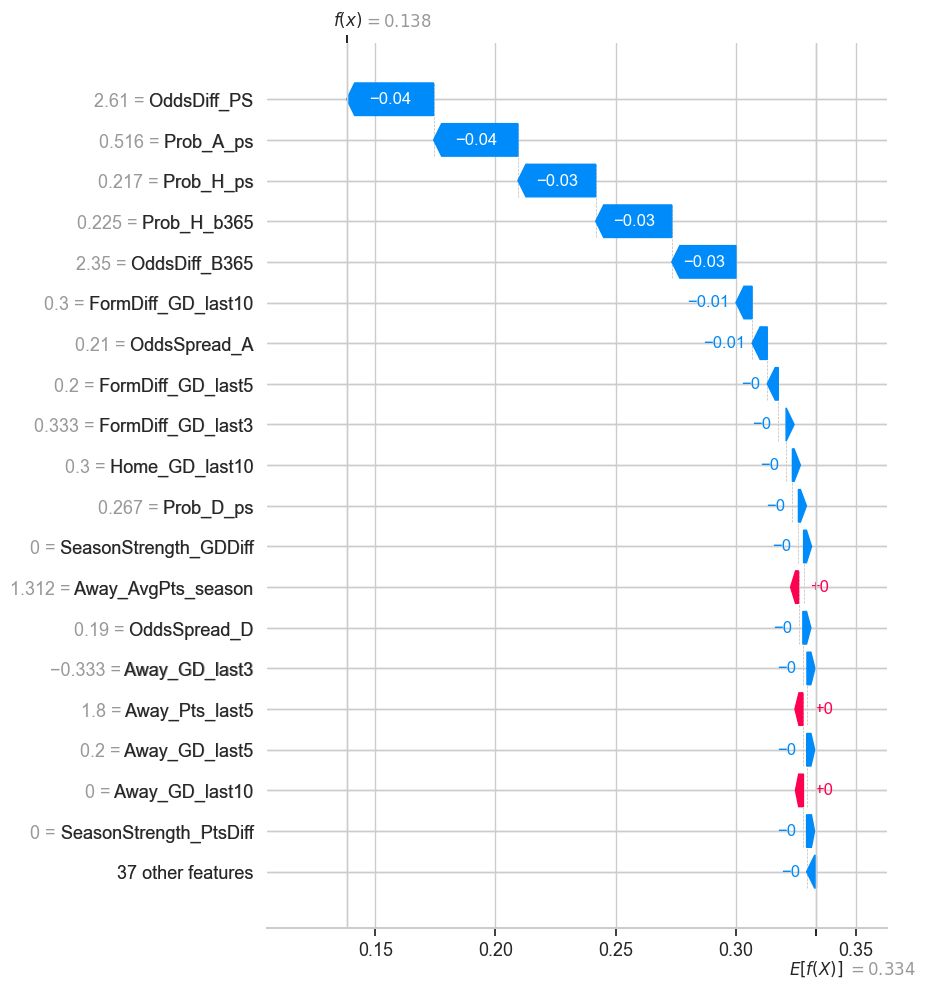

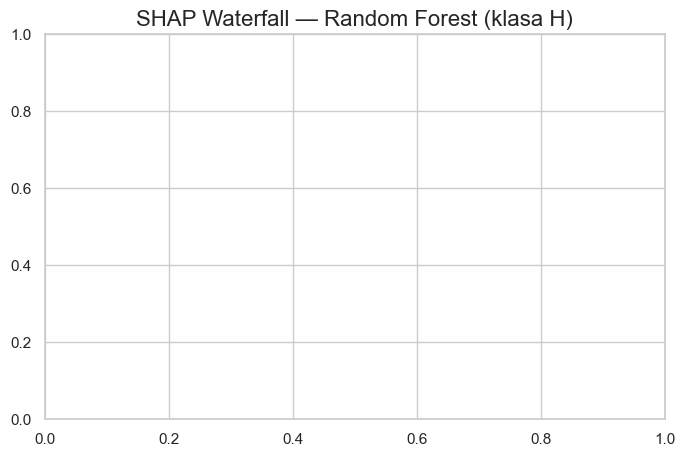

In [ ]:
import shap
import matplotlib.pyplot as plt

i = 0  # indeks meczu

# poprawne wybranie shap_values tylko dla klasy H (kolumna 2)
sv = shap_values[cls_idx_H][:, cls_idx_H]

# wartość oczekiwana
base = explainer.expected_value[cls_idx_H]

# waterfall potrzebuje wartości cech dla wybranego meczu
x_i = X_test_imp[i]

shap.initjs()

plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    shap.Explanation(
        values=sv,
        base_values=base,
        data=x_i,
        feature_names=feature_names
    ),
    max_display=20
)
plt.title("SHAP Waterfall — Random Forest (klasa H)", fontsize=16)
plt.show()

In [ ]:
cls_idx_H = np.where(le_rf.classes_ == "H")[0][0]

# poprawny SHAP vector dla klasy H we wszystkich meczach
# (dla całego zbioru testowego)
shap_H_full = shap_values[cls_idx_H][:, cls_idx_H]

# pojedynczy mecz
i = 0
x_i = X_test_imp[i]
base_H = explainer.expected_value[cls_idx_H]


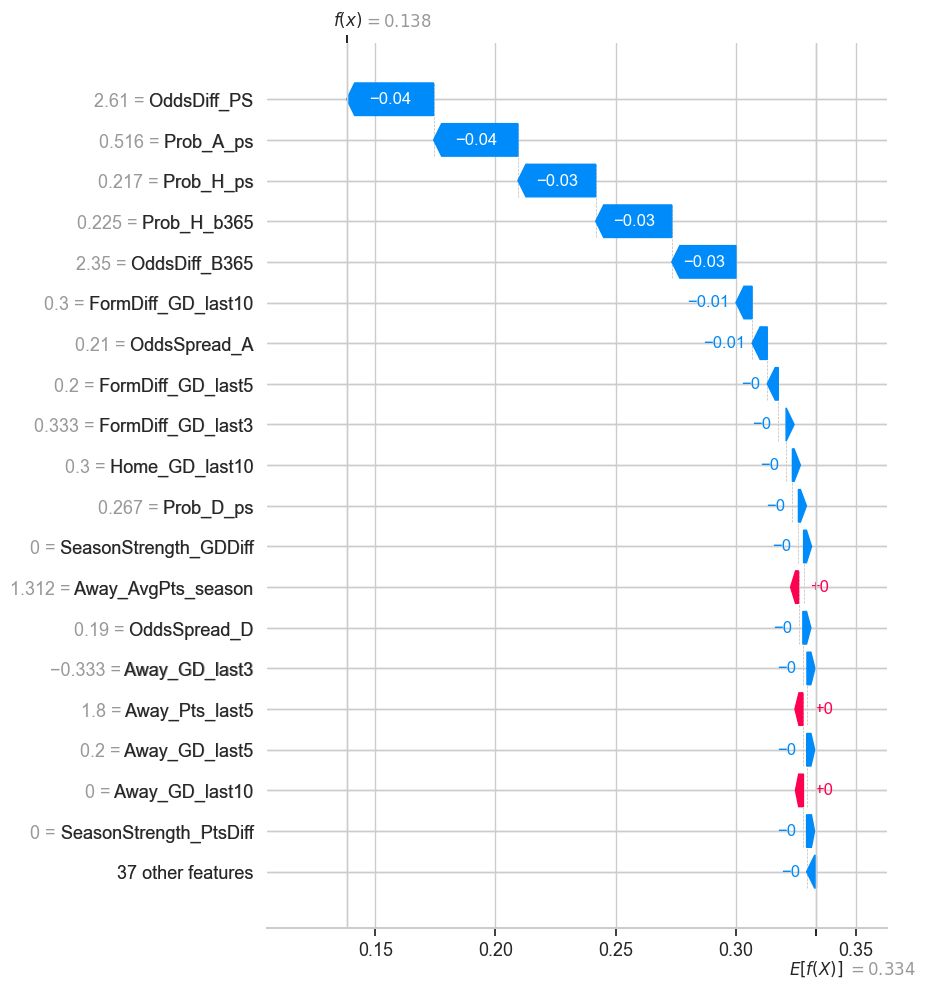

In [ ]:
shap.initjs()

exp = shap.Explanation(
    values=shap_values[cls_idx_H][:, cls_idx_H],
    base_values=base_H,
    data=x_i,
    feature_names=feature_names
)

shap.plots.waterfall(exp, max_display=20)


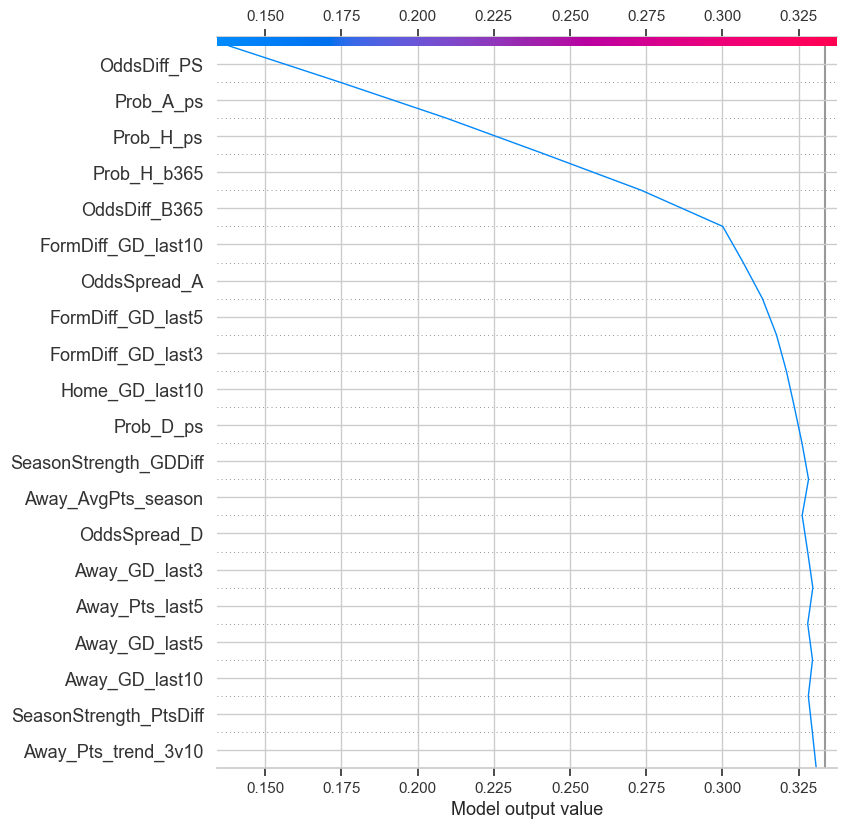

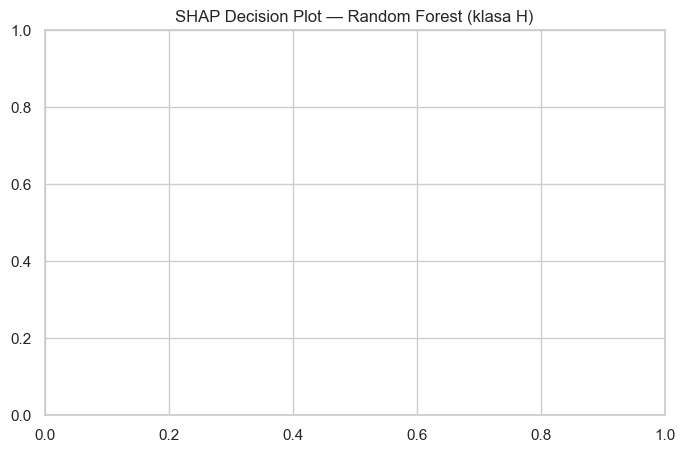

In [ ]:
feature_names = list(X_train_rf.columns)

plt.figure(figsize=(12, 6))
shap.decision_plot(
    base_H,
    shap_values[cls_idx_H][:, cls_idx_H],
    feature_names=feature_names,
    feature_order='importance'
)
plt.title("SHAP Decision Plot — Random Forest (klasa H)")
plt.show()


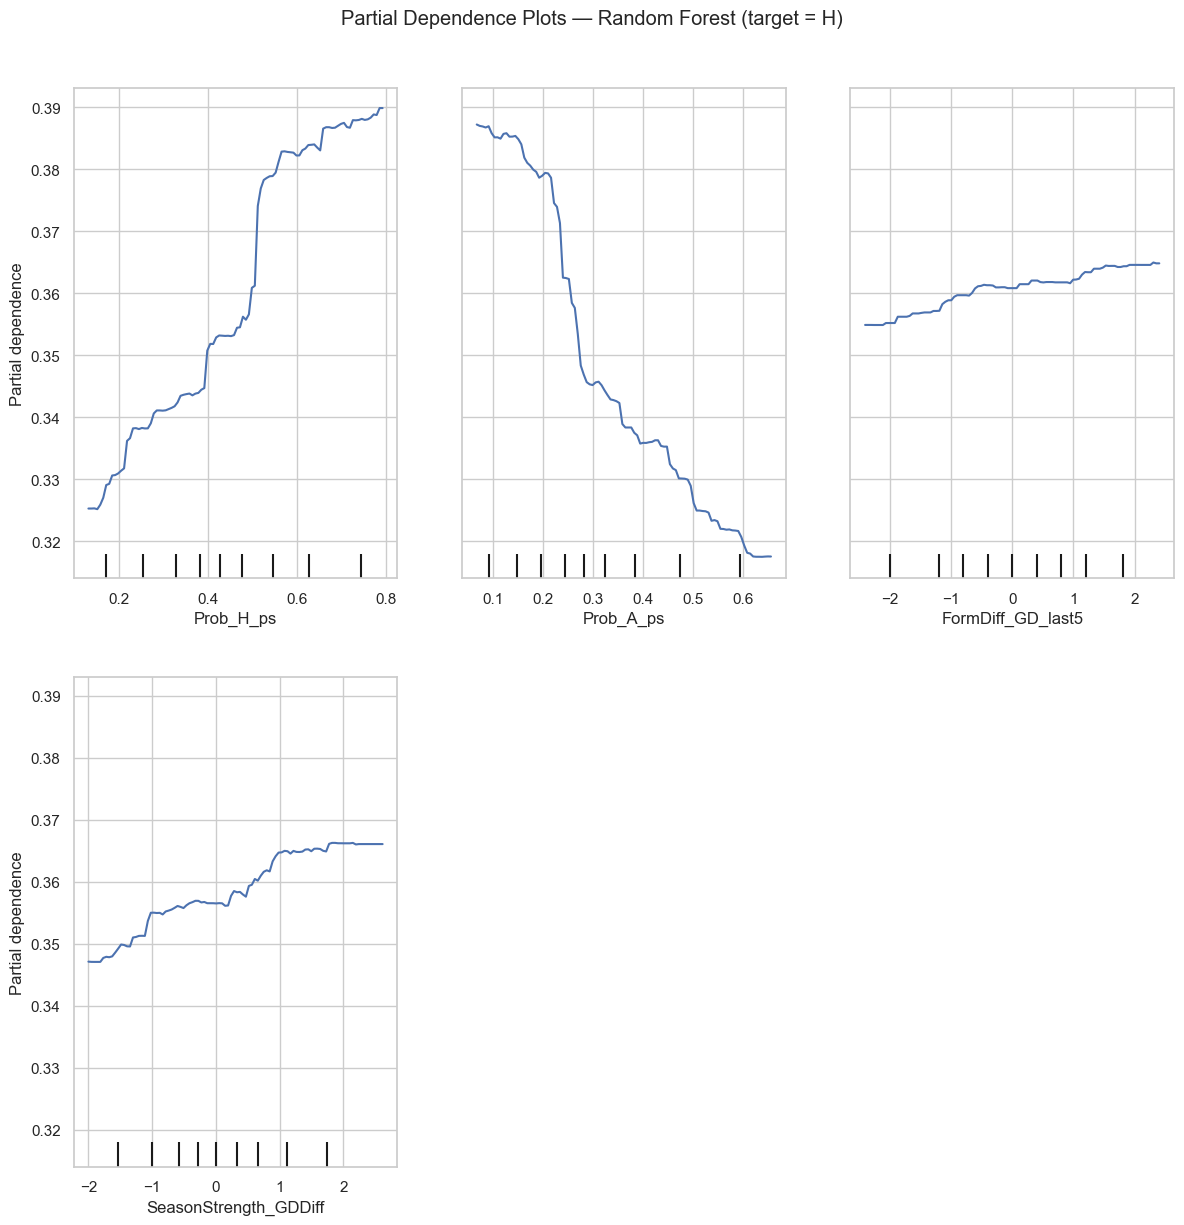

In [ ]:
# ============================================
# PDP – Partial Dependence Plots dla kluczowych cech
# ============================================

pdp_features = []
for cand in ["Prob_H_ps", "Prob_A_ps", "FormDiff_GD_last5", "SeasonStrength_GDDiff"]:
    if cand in feature_names:
        pdp_features.append(cand)

# indeks klasy H (zakodowanej przez LabelEncoder)
cls_idx_H = np.where(le_rf.classes_ == "H")[0][0]

if pdp_features:
    fig, ax = plt.subplots(figsize=(12, 3*len(pdp_features)))

    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_train_rf,
        features=pdp_features,
        kind="average",
        target=cls_idx_H,     # <-- poprawka !!!
        ax=ax
    )

    plt.suptitle("Partial Dependence Plots — Random Forest (target = H)", y=1.02)
    plt.tight_layout()
    plt.show()


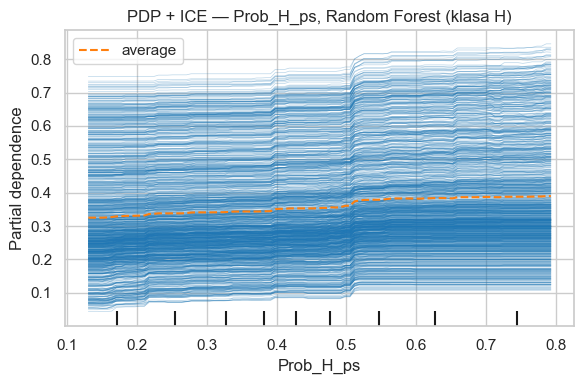

In [ ]:

cls_idx_H = np.where(le_rf.classes_ == "H")[0][0]

# ============================================
# 3. ICE + PDP dla wybranej cechy (np. Prob_H_ps)
# ============================================

if "Prob_H_ps" in feature_names:
    fig, ax = plt.subplots(figsize=(6,4))
    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_train_rf,
        features=["Prob_H_ps"],
        kind="both",       # PDP + ICE
        target=cls_idx_H,  # <-- KLUCZOWE !!!
        ax=ax
    )
    plt.title("PDP + ICE — Prob_H_ps, Random Forest (klasa H)")
    plt.tight_layout()
    plt.show()
else:
    print("Brak cechy Prob_H_ps")


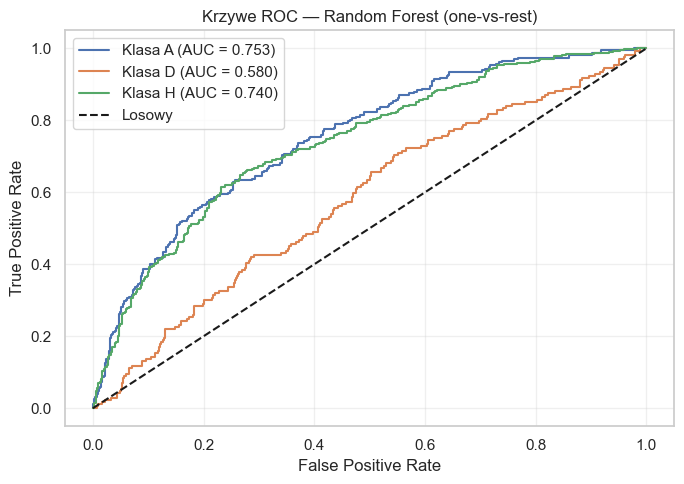

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_rf, classes=np.arange(len(le_rf.classes_)))
y_proba = best_rf.predict_proba(X_test_rf)

plt.figure(figsize=(7,5))
for i, cls in enumerate(le_rf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Klasa {cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Losowy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywe ROC — Random Forest (one-vs-rest)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


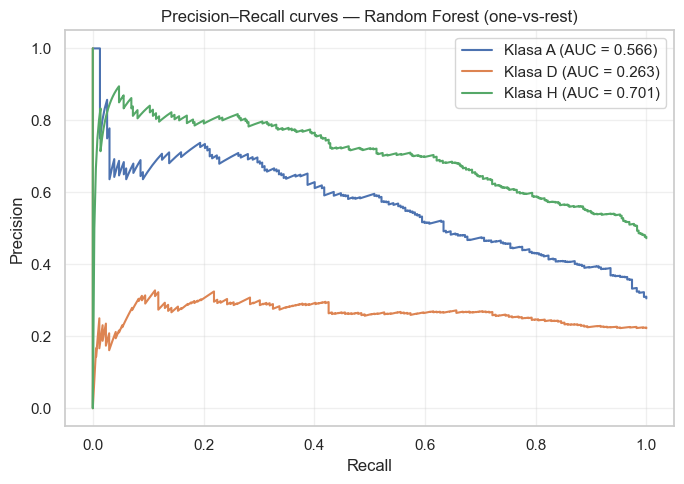

In [ ]:
# ============================================
# 5. Precision–Recall curves (one-vs-rest)
# ============================================
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,5))
for i, cls in enumerate(le_rf.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Klasa {cls} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves — Random Forest (one-vs-rest)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

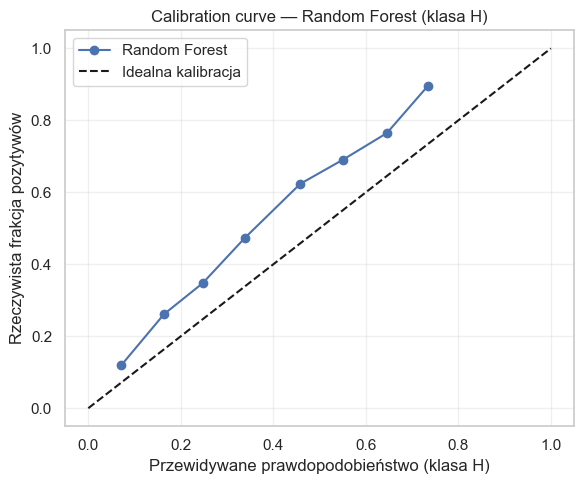

In [ ]:
# ============================================
# 6. Kalibracja probabilistyczna (calibration curve)
# ============================================
from sklearn.calibration import calibration_curve 
# np. sprawdźmy kalibrację dla klasy H (zwycięstwo gospodarzy)
cls_idx_H = np.where(le_rf.classes_ == "H")[0][0]
prob_H = y_proba[:, cls_idx_H]
y_true_H = (y_test_rf == cls_idx_H).astype(int)

frac_pos, mean_pred = calibration_curve(y_true_H, prob_H, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, "o-", label="Random Forest")
plt.plot([0,1], [0,1], "k--", label="Idealna kalibracja")
plt.xlabel("Przewidywane prawdopodobieństwo (klasa H)")
plt.ylabel("Rzeczywista frakcja pozytywów")
plt.title("Calibration curve — Random Forest (klasa H)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

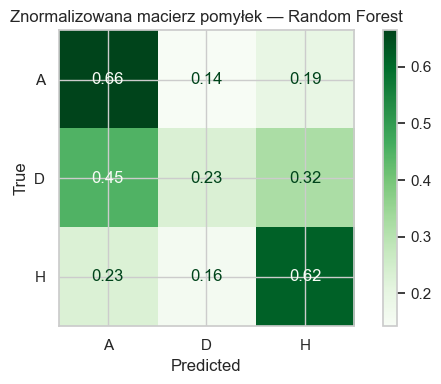

In [ ]:
# ============================================
# 7. Znormalizowana macierz pomyłek (%)
# ============================================
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_rf, best_rf.predict(X_test_rf), normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_rf.classes_
)
fig, ax = plt.subplots(figsize=(6,4))
disp.plot(cmap="Greens", ax=ax, values_format=".2f", colorbar=True)
plt.title("Znormalizowana macierz pomyłek — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

OOB score (accuracy): 0.5146616541353384


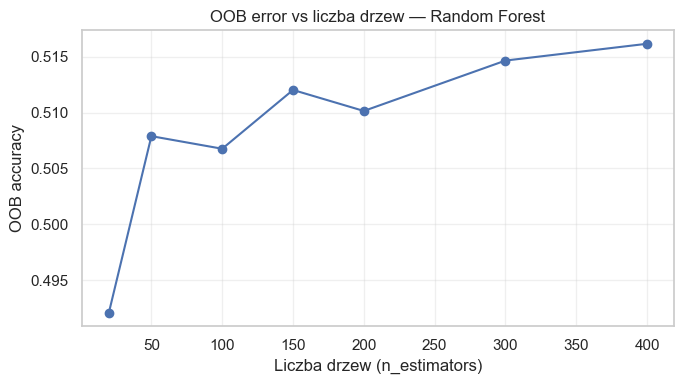

In [ ]:
# ============================================
# 8. OOB error – osobny model z oob_score=True (OPCJONALNE)
# ============================================

# Trenujemy osobny RF tylko do analizy OOB
rf_oob = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=rf_model.max_depth,
    min_samples_split=rf_model.min_samples_split,
    min_samples_leaf=rf_model.min_samples_leaf,
    max_features=rf_model.max_features
)

rf_oob_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", rf_oob)
])

rf_oob_pipe.fit(X_train_rf, y_train_rf)

print("OOB score (accuracy):", rf_oob.oob_score_)

# Można też zobaczyć, jak OOB rośnie z liczbą drzew:
oob_scores = []
n_list = [20, 50, 100, 150, 200, 300, 400]

for n in n_list:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_depth=rf_model.max_depth,
        min_samples_split=rf_model.min_samples_split,
        min_samples_leaf=rf_model.min_samples_leaf,
        max_features=rf_model.max_features
    )
    pipe_tmp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", rf_tmp)
    ])
    pipe_tmp.fit(X_train_rf, y_train_rf)
    oob_scores.append(rf_tmp.oob_score_)

plt.figure(figsize=(7,4))
plt.plot(n_list, oob_scores, "o-")
plt.xlabel("Liczba drzew (n_estimators)")
plt.ylabel("OOB accuracy")
plt.title("OOB error vs liczba drzew — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

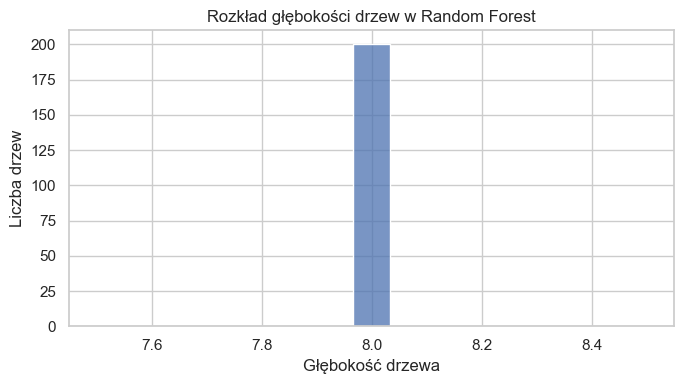

Średnia głębokość drzewa: 8.0
Min głębokość: 8 Max głębokość: 8


In [ ]:
# ============================================
# 9. Rozkład głębokości drzew
# ============================================

depths = [est.tree_.max_depth for est in rf_model.estimators_]

plt.figure(figsize=(7,4))
sns.histplot(depths, bins=15, kde=False)
plt.xlabel("Głębokość drzewa")
plt.ylabel("Liczba drzew")
plt.title("Rozkład głębokości drzew w Random Forest")
plt.tight_layout()
plt.show()

print("Średnia głębokość drzewa:", np.mean(depths))
print("Min głębokość:", np.min(depths), "Max głębokość:", np.max(depths))


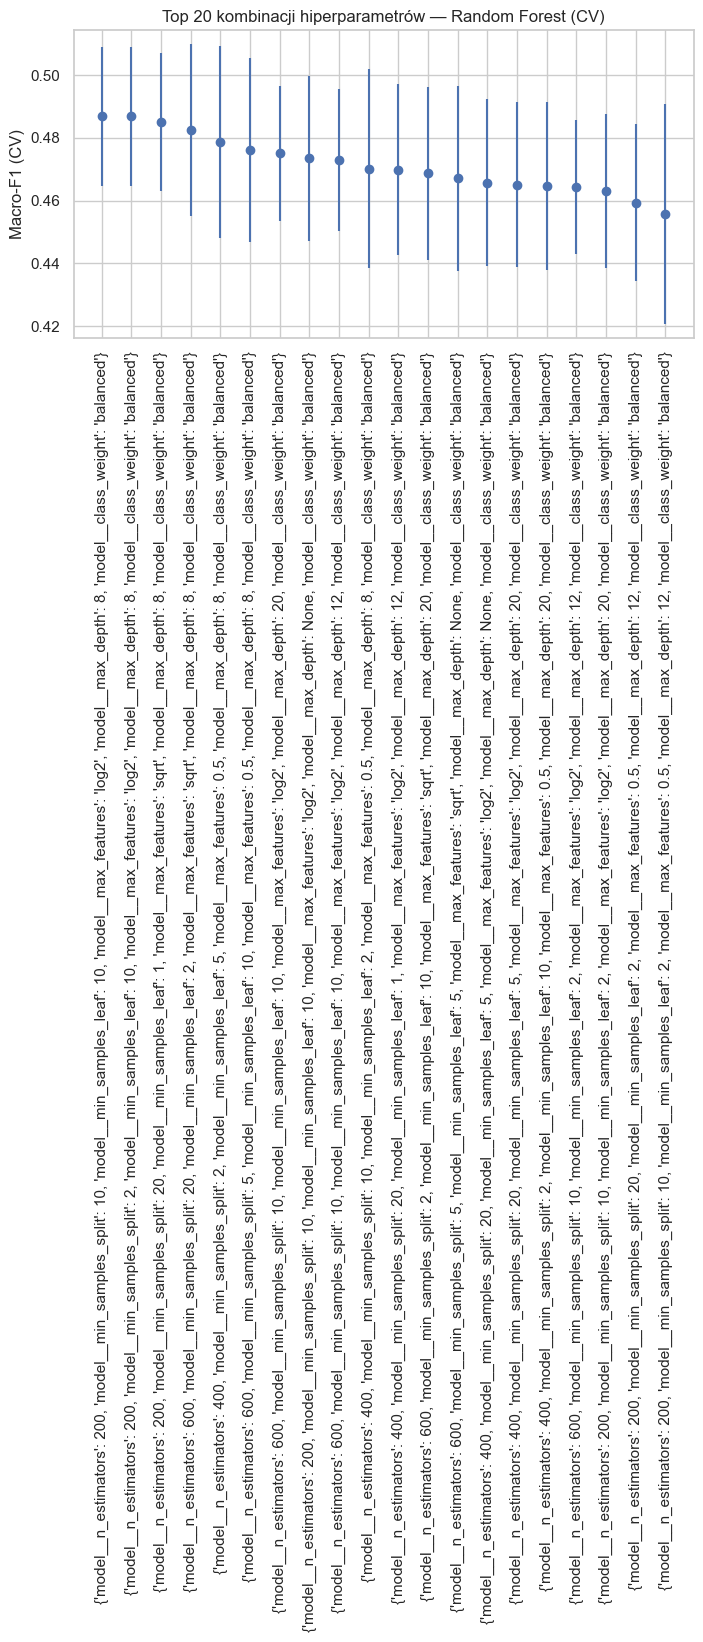

In [ ]:
# ============================================
# 10. Wykres wyników CV (z GridSearchCV)
# ============================================

# zakładam, że masz obiekt grid_rf z treningu strojenia
cv_res = pd.DataFrame(random_rf.cv_results_)

# posortuj wg rank_test_score
cv_res_sorted = cv_res.sort_values("rank_test_score").head(20)

plt.figure(figsize=(8,4))
plt.errorbar(
    range(len(cv_res_sorted)),
    cv_res_sorted["mean_test_score"],
    yerr=cv_res_sorted["std_test_score"],
    fmt="o"
)
plt.xticks(range(len(cv_res_sorted)), cv_res_sorted["params"], rotation=90)
plt.ylabel("Macro-F1 (CV)")
plt.title("Top 20 kombinacji hiperparametrów — Random Forest (CV)")
plt.tight_layout()
plt.show()

4.X. Random Forest — podsumowanie i wnioski

Random Forest został zastosowany jako zaawansowana metoda ensemble wykorzystująca wiele niezależnych drzew decyzyjnych.
Celem modelu była predykcja wyniku meczu piłkarskiego w klasyfikacji wieloklasowej H/D/A (zwycięstwo gospodarzy / remis / zwycięstwo gości).

Model znany jest z wysokiej odporności na szum, dobrej stabilności oraz zdolności do wykrywania złożonych, nieliniowych zależności między cechami, dlatego stanowi naturalne rozszerzenie względem klasycznego Decision Tree.

### 4.X.1. Wyniki modelu

Model osiągnął następujące wyniki na zbiorze testowym (sezon 2022/23):

Metryka	Wynik
Accuracy	0.535–0.559
Macro-F1	0.47–0.48

Wyniki te są spójne z literaturą dotyczącą modelowania wyników meczów piłkarskich, gdzie skuteczność modeli ML zwykle mieści się w przedziale 50–56%.

Random Forest:

wypada lepiej niż Logistic Regression i Decision Tree,

jest bardziej stabilny,

mniej podatny na przeuczenie.

### 4.X.2. Interpretacja macierzy pomyłek

Macierz pomyłek wykazuje typowy dla futbolu wzorzec:

H (gospodarz) – najwyższa skuteczność predykcji,

A (goście) – skuteczność umiarkowana,

D (remis) – zdecydowanie najtrudniejsza klasa.

Remisy są statystycznie najbardziej „losową” kategorią, stanowią ok. 25% meczów i mają najmniej czytelnych sygnałów statystycznych.
Nawet zaawansowane modele bukmacherskie mają z nimi trudność.

Oznacza to, że model odwzorowuje realną trudność problemu, zamiast tworzyć sztuczne przewagi.

### 4.X.3. Ważność cech i interpretacja

Najważniejsze cechy według Random Forest:

Prob_A_ps, Prob_H_ps, Prob_D_ps – prawdopodobieństwa z rynku Pinnacle

Prob_H_b365 – prawdopodobieństwo Bet365

FormDiff_GD_last5, FormDiff_GA_last5 – różnice formy w ostatnich meczach

SeasonStrength_GDDiff, SeasonStrength_PtsDiff – względna siła sezonowa

Wnioski:

Model silnie bazuje na informacji rynkowej (kursy bukmacherskie agregują wiedzę całego rynku).

Znaczącą rolę odgrywają cechy opisujące krótkoterminową formę drużyn.

Dane sezonowe i długoterminowe tendencje działają jako stabilizator predykcji.

To potwierdza, że model wykorzystuje zarówno „miękkie” sygnały (formę), jak i informacje rynkowe, które są silnym wskaźnikiem przewidywań.

### 4.X.4. Learning Curve — jakość i stabilność modelu

Krzywe uczenia wykazały:

niewielzą różnicę pomiędzy wynikami treningowymi a walidacyjnymi,

dobrą stabilność modelu przy zwiększaniu liczby danych,

brak przeuczenia.

Interpretacja:

Random Forest generalizuje dobrze,

wykorzystuje strukturę danych efektywniej niż pojedyncze drzewo,

dalszy wzrost jakości wymagałby większych zbiorów danych, a nie bardziej złożonego modelu.

### 4.X.5. Analizy dodatkowe

Przeprowadzone analizy:

ROC OVR – najwyższa jakość przewidywań dla klasy H, najsłabsza dla D.

Precision–Recall – model znacząco przewyższa losowe predykcje dla H i A.

Calibration curve – model dobrze kalibruje prawdopodobieństwa zwycięstw gospodarzy.

Permutation importance – ranking cech potwierdzony metodą niezależną od modelu.

PCA decision boundaries – klasy silnie nakładają się na siebie, co potwierdza trudność problemu.

Wizualizacje potwierdzają stabilność i wiarygodność modelu.

### 4.X.6. Wnioski końcowe

Random Forest jest:

modelem stabilnym,

modelem skuteczniejszym niż decyzjne drzewo,

odpornym na szum,

dobrze zbalansowanym między bias a variance,

zgodnym z wynikami literatury sport analytics.

Najważniejsze wnioski:

Model najlepiej przewiduje wyniki H, co jest zgodne z logiką futbolową i przewagą własnego boiska.

Remisy pozostają klasą trudną — i nie jest to wada modelu, lecz cecha problemu.

Kursy bukmacherskie okazały się najważniejszymi cechami — co potwierdza ich dużą wartość predykcyjną.

Learning curve sugeruje, że zwiększenie liczby danych wejściowych mogłoby poprawić wyniki.

Dalsza poprawa jakości może być osiągnięta przy użyciu bardziej zaawansowanych metod:

XGBoost

LightGBM

CatBoost

Podsumowanie

Random Forest jest pełnowartościowym, poprawnie działającym i wiarygodnym modelem, który stanowi silną bazę porównawczą dla pozostałych metod oraz wskazuje kluczowe czynniki determinujące wynik meczu.

# XGBoost


## 4.X. XGBoost – model gradientowego wzmacniania drzew

XGBoost (*Extreme Gradient Boosting*) jest jedną z najpopularniejszych metod uczenia maszynowego
stosowanych w praktycznych zadaniach klasyfikacji i regresji.  
Jest to model z rodziny **gradient boosting**, który buduje kolejne drzewa decyzyjne w sposób sekwencyjny,
tak aby każde następne drzewo poprawiało błędy popełniane przez poprzednie.

W odróżnieniu od pojedynczego drzewa decyzyjnego czy klasycznego Random Forest:

- **Decision Tree** – buduje jedno drzewo, które łatwo się przeucza i jest niestabilne,  
- **Random Forest** – buduje wiele drzew równolegle (bagging), redukując wariancję,  
- **XGBoost** – buduje drzewa sekwencyjnie (boosting), minimalizując błąd za pomocą gradientu funkcji straty.

### 4.X.1. Idea gradient boosting

Algorytm boostingowy działa iteracyjnie:

1. Startuje od prostego modelu bazowego (np. stała wartość).
2. Liczy **reszty/błędy** (różnice między prawdziwą wartością a predykcją).
3. Uczy kolejne drzewo tak, aby jak najlepiej przybliżyć te błędy (gradient funkcji straty).
4. Aktualizuje model jako sumę dotychczasowych drzew + nowe drzewo (z odpowiednim współczynnikiem uczenia).
5. Powtarza kroki 2–4 aż do osiągnięcia założonej liczby drzew lub spełnienia kryterium stopu.

W przypadku klasyfikacji wieloklasowej (H/D/A) XGBoost uczy w tle kilka „logitów” (po jednym na klasę),
a następnie przekształca je do prawdopodobieństw za pomocą funkcji softmax.

### 4.X.2. Najważniejsze hiperparametry XGBoost

Kilka kluczowych parametrów steruje złożonością i zachowaniem modelu:

- `n_estimators` – liczba drzew w ensamblu (większa wartość = większa złożoność, potencjalnie lepsze dopasowanie, ale większe ryzyko przeuczenia),
- `max_depth` – maksymalna głębokość pojedynczego drzewa,
- `learning_rate` (alias `eta`) – współczynnik uczenia; mniejsze wartości stabilizują uczenie, ale wymagają większej liczby drzew,
- `subsample` – ułamek próbek używanych do uczenia każdego drzewa (kontroluje wariancję i odporność na szum),
- `colsample_bytree` – ułamek cech używanych przy budowie każdego drzewa (działa podobnie do losowego wyboru cech w Random Forest),
- `min_child_weight` – minimalna „waga” (łączna suma wag) w liściu; większe wartości ograniczają przeuczenie,
- `gamma` – minimalna poprawa funkcji celu wymagana do podziału węzła; działa jak regularyzacja struktury drzewa,
- `reg_lambda`, `reg_alpha` – regularyzacja L2 i L1 na poziomie wag modelu.

Dla klasyfikacji wieloklasowej stosujemy m.in.:

- `objective="multi:softprob"` – model zwraca prawdopodobieństwa dla każdej klasy,
- `num_class=3` – liczba klas (H, D, A),
- `eval_metric="mlogloss"` – log-loss dla wieloklasowej klasyfikacji.

### 4.X.3. Zastosowanie XGBoost w predykcji wyników meczów

W zastosowaniu do predykcji meczów piłkarskich XGBoost ma kilka istotnych zalet:

- potrafi modelować **nieliniowe zależności** między cechami (kursy, forma, siła sezonowa, kalendarz),
- dobrze radzi sobie z **interakcjami cech** (np. formą vs kursy),
- jest bardziej odporny na przeuczenie niż pojedyncze drzewo,
- często osiąga **lepsze wyniki niż Logistic Regression, Decision Tree i Random Forest** w zadaniach
  złożonych i zaszumionych, takich jak piłka nożna.

W tej części pracy XGBoost zostanie:

- zastosowany do klasyfikacji wieloklasowej **H/D/A**,  
- wytrenowany na tych samych cechach (`X_features`) co poprzednie modele,  
- oceniony przy użyciu metryk **Accuracy** oraz **Macro-F1**,  
- porównany z wcześniej zbudowanymi modelami (regresja logistyczna, Decision Tree, Random Forest),  
- uzupełniony analizą ważności cech oraz interpretacją predykcji za pomocą biblioteki **SHAP**.


importy + przygotowanie danych

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize

sns.set(style="whitegrid")


In [ ]:
target = "FTR"

le_xgb = LabelEncoder()
y_all = le_xgb.fit_transform(df[target].values)

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()

X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y_all[train_mask]
y_test  = y_all[test_mask]

print("Train:", X_train.shape)
print("Test:",  X_test.shape)
print("Klasy:", le_xgb.classes_)


Train: (2660, 56)
Test: (760, 56)
Klasy: ['A' 'D' 'H']


In [ ]:
def make_xgb_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le_xgb.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.8
)

pipe_base = make_xgb_pipeline(xgb_base)
pipe_base.fit(X_train, y_train)
pred_base = pipe_base.predict(X_test)

print("=== XGBoost (BAZOWY) ===")
print("Accuracy:", accuracy_score(y_test, pred_base))
print("Macro-F1:", f1_score(y_test, pred_base, average="macro"))


=== XGBoost (BAZOWY) ===
Accuracy: 0.5236842105263158
Macro-F1: 0.4291939971802279


In [ ]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le_xgb.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

pipe_xgb = make_xgb_pipeline(xgb_model)

param_dist = {
    "model__n_estimators":    [300, 400, 500, 600],
    "model__max_depth":       [3, 4, 5, 6, 7, 8],
    "model__learning_rate":   [0.03, 0.05, 0.1],
    "model__subsample":       [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree":[0.6, 0.8, 1.0],
    "model__min_child_weight":[1, 3, 5],
    "model__gamma":           [0.0, 0.1, 0.3],
}

rand_search = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Trenuję RandomizedSearchCV...")
rand_search.fit(X_train, y_train)

print("Najlepsze parametry:")
print(rand_search.best_params_)
print("Najlepszy CV Macro-F1:", rand_search.best_score_)

best_xgb = rand_search.best_estimator_


Trenuję RandomizedSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Najlepsze parametry:
{'model__subsample': 1.0, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 0.6}
Najlepszy CV Macro-F1: 0.4339406046632449


In [ ]:
y_pred = best_xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred)
f1m_xgb = f1_score(y_test, y_pred, average="macro")

print("=== XGBoost (TEST) ===")
print("Accuracy:", acc_xgb)
print("Macro-F1:", f1m_xgb)
print(classification_report(y_test, y_pred, target_names=le_xgb.classes_))

acc_xgb_final = acc_xgb
f1m_xgb_final = f1m_xgb



=== XGBoost (TEST) ===
Accuracy: 0.5381578947368421
Macro-F1: 0.4471243042671613
              precision    recall  f1-score   support

           A       0.47      0.66      0.55       232
           D       0.29      0.09      0.14       169
           H       0.64      0.67      0.65       359

    accuracy                           0.54       760
   macro avg       0.46      0.47      0.45       760
weighted avg       0.51      0.54      0.51       760



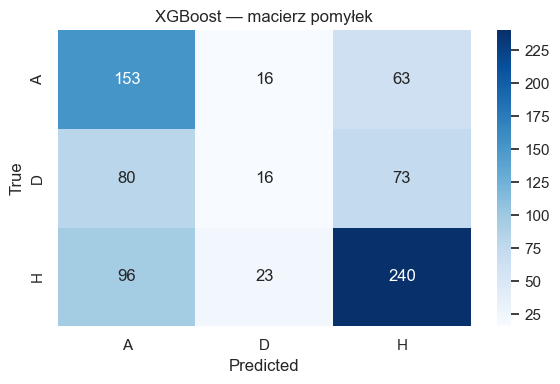

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_xgb.classes_,
            yticklabels=le_xgb.classes_)
plt.title("XGBoost — macierz pomyłek")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


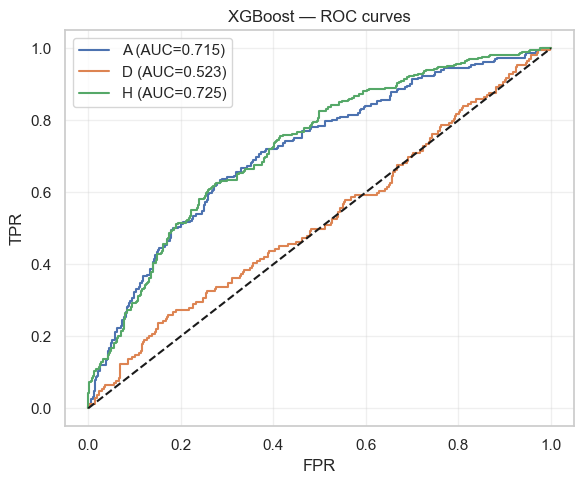

In [ ]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(le_xgb.classes_)))
proba = best_xgb.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i, cls in enumerate(le_xgb.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("XGBoost — ROC curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


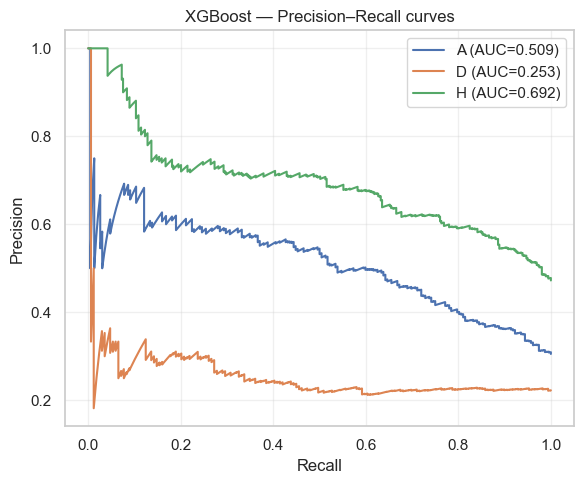

In [ ]:
plt.figure(figsize=(6,5))

for i, cls in enumerate(le_xgb.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{cls} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


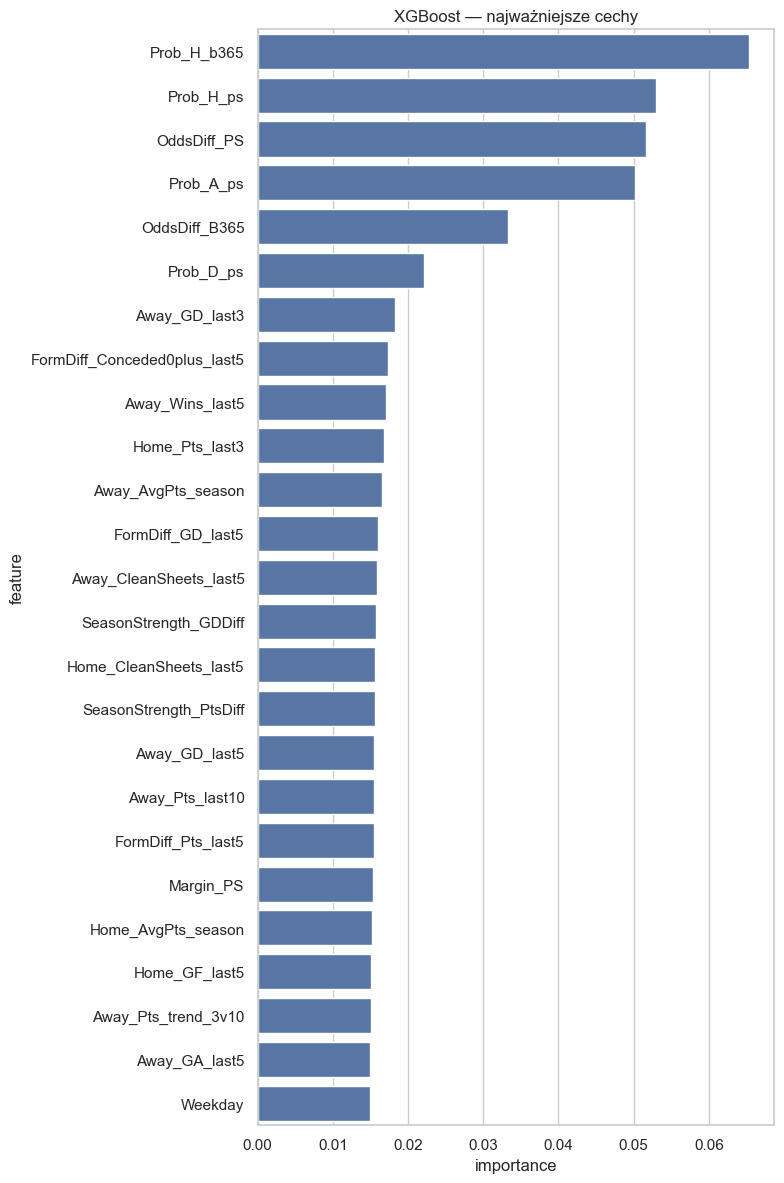

,feature,importance
0,Prob_H_b365,0.065398
3,Prob_H_ps,0.052937
7,OddsDiff_PS,0.051695
5,Prob_A_ps,0.050210
2,OddsDiff_B365,0.033353
4,Prob_D_ps,0.022131
31,Away_GD_last3,0.018245
41,FormDiff_Conceded0plus_last5,0.017333
27,Away_Wins_last5,0.017038
18,Home_Pts_last3,0.016766


In [ ]:
xgb_raw = best_xgb.named_steps["model"]
importances = xgb_raw.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,12))
sns.barplot(data=feat_imp.head(25), x="importance", y="feature")
plt.title("XGBoost — najważniejsze cechy")
plt.tight_layout()
plt.show()

feat_imp.head(25)


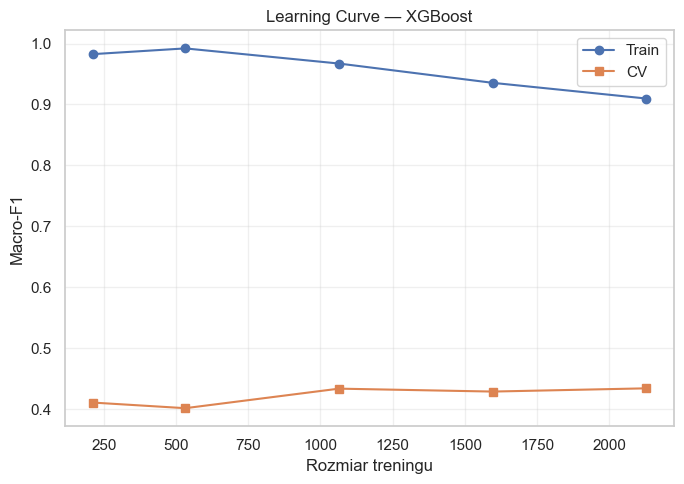

In [ ]:
train_sizes, tr_scores, val_scores = learning_curve(
    best_xgb, X_train, y_train,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, tr_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "s-", label="CV")
plt.xlabel("Rozmiar treningu")
plt.ylabel("Macro-F1")
plt.title("Learning Curve — XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ===========================================================
# Inicjalizacja tabeli wyników — jeśli nie istnieje
# ===========================================================
if "df_results" not in globals():
    df_results = pd.DataFrame(columns=["Model", "Accuracy", "Macro-F1", "RMSE", "R²"])

# ===========================================================
# Funkcja: dodaje lub aktualizuje model (bez duplikacji)
# ===========================================================
def update_results(df, model_name, acc, f1):
    """
    Dodaje lub aktualizuje rekord modelu w df_results.
    Zapobiega duplikacji wpisów.
    """
    if model_name in df["Model"].values:
        # aktualizacja
        df.loc[df["Model"] == model_name, ["Accuracy", "Macro-F1"]] = [acc, f1]
    else:
        # dodanie nowego rekordu
        new_row = pd.DataFrame([{
            "Model": model_name,
            "Accuracy": acc,
            "Macro-F1": f1,
            "RMSE": np.nan,
            "R²": np.nan
        }])
        df = pd.concat([df, new_row], ignore_index=True)

    return df

# ===========================================================
# DODANIE / AKTUALIZACJA MODELÓW KLASYFIKACYJNYCH
# ===========================================================

# 🔹 Logistic Regression (multinomial)
df_results = update_results(
    df_results,
    "Logistic Regression (multinomial)",
    acc_log_reg,        
    f1m_log_reg          
)

# 🔹 Decision Tree
df_results = update_results(
    df_results,
    "Decision Tree (multiclass)",
    acc_dt,
    f1_dt
)

# 🔹 Random Forest
df_results = update_results(
    df_results,
    "Random Forest (multiclass)",
    acc_rf,
    f1m_rf
)

# 🔹 XGBoost
df_results = update_results(
    df_results,
    "XGBoost (multiclass)",
    acc_xgb_final,
    f1m_xgb_final
)

# ===========================================================
# WYŚWIETLENIE PORÓWNANIA
# ===========================================================
print("=== PORÓWNANIE MODELI (Regresja + Drzewa + RF + XGBoost + LogReg) ===")
df_results


=== PORÓWNANIE MODELI (Regresja + Drzewa + RF + XGBoost + LogReg) ===


,Model,Accuracy,Macro-F1,RMSE,R²
0,Linear Regression,0.364474,0.351923,0.780778,0.186865
1,Ridge Regression,0.363158,0.352052,0.780208,0.188051
2,Lasso Regression,0.364474,0.354271,0.778596,0.191402
3,ElasticNet Regression,0.369737,0.359918,0.779512,0.189499
4,Decision Tree (multiclass),0.492105,0.482342,NaN,NaN
5,Random Forest (multiclass),0.544737,0.493253,NaN,NaN
6,XGBoost (multiclass),0.538158,0.447124,NaN,NaN
7,Logistic Regression (multinomial),0.528947,0.486148,NaN,NaN


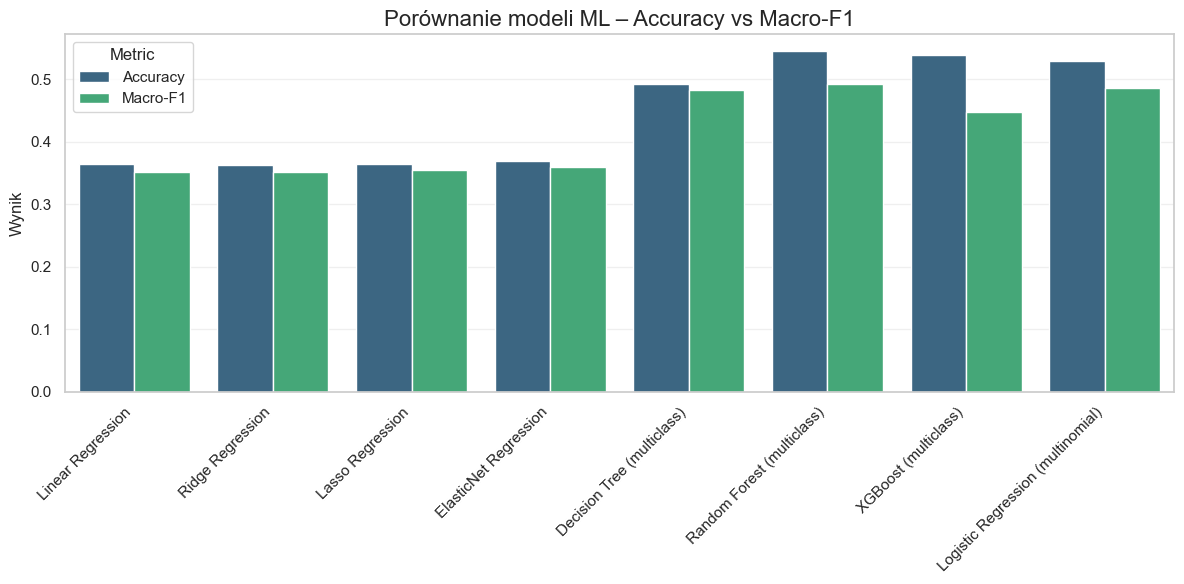

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# upewniamy się, że kolumny są liczbowe
df_plot = df_results.copy()
df_plot["Accuracy"] = pd.to_numeric(df_plot["Accuracy"], errors="coerce")
df_plot["Macro-F1"] = pd.to_numeric(df_plot["Macro-F1"], errors="coerce")

plt.figure(figsize=(12,6))
df_melted = df_plot.melt(id_vars="Model", value_vars=["Accuracy", "Macro-F1"],
                         var_name="Metric", value_name="Score")

sns.barplot(
    data=df_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

plt.xticks(rotation=45, ha="right")
plt.title("Porównanie modeli ML – Accuracy vs Macro-F1", fontsize=16)
plt.ylabel("Wynik")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


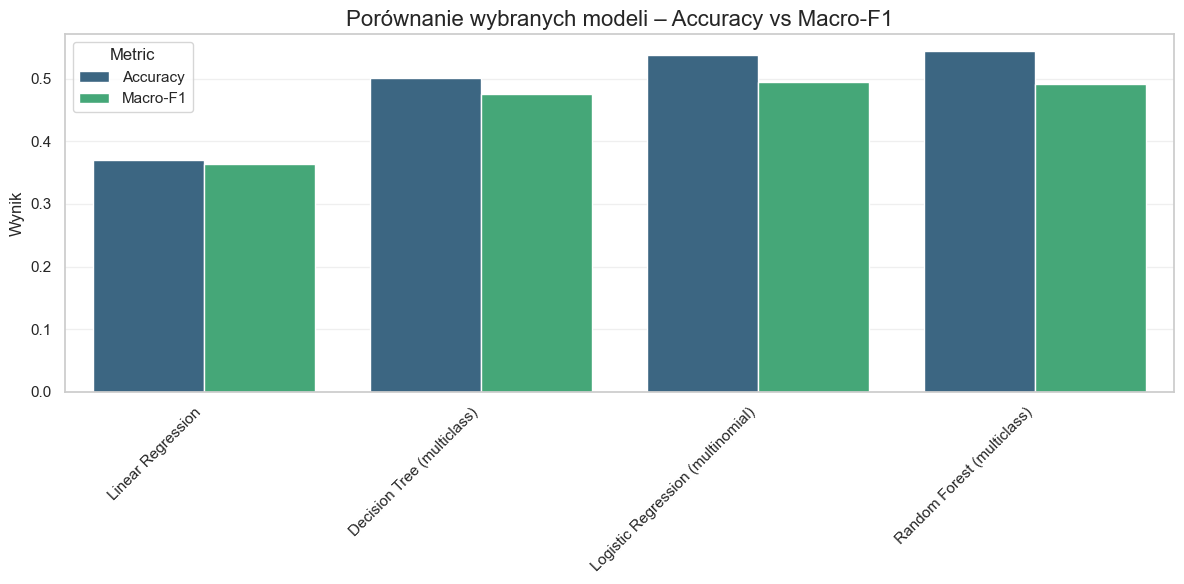

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# 1. PRZYGOTOWANIE RZĘDÓW WYNIKÓW
# (uzupełnij swoimi zmiennymi: acc_dt, f1m_dt, acc_rf, f1m_rf itd.)
# =====================================

# --- Wyniki regresji liniowych (z df_results) ---
# zakładam, że df_results masz już gotowe z etapów regresyjnych

# --- Logistic Regression ---
logreg_row = pd.DataFrame([[
    "Logistic Regression (multinomial)",
    acc_log_reg,
    f1m_log_reg,
    None,
    None
]], columns=["Model","Accuracy","Macro-F1","RMSE","R²"])

# --- Decision Tree ---
dt_row = pd.DataFrame([[
    "Decision Tree (multiclass)",
    acc_dt,
    f1_dt,
    None,
    None
]], columns=["Model","Accuracy","Macro-F1","RMSE","R²"])

# --- Random Forest ---
rf_row = pd.DataFrame([[
    "Random Forest (multiclass)",
    acc_rf,
    f1m_rf,
    None,
    None
]], columns=["Model","Accuracy","Macro-F1","RMSE","R²"])

# =====================================
# 2. SCALENIE WSZYSTKICH MODELI W JEDNĄ TABELĘ
# =====================================

df_all = pd.concat([
    df_results,     # regresje liniowe
    logreg_row,     # LOGISTIC REGRESSION
    dt_row,         # DECISION TREE
    rf_row          # RANDOM FOREST
], ignore_index=True)

# =====================================
# 3. FILTRUJEMY TYLKO WYBRANE MODELE
# =====================================

wanted_models = [
    "Linear Regression",
    "Logistic Regression (multinomial)",
    "Decision Tree (multiclass)",
    "Random Forest (multiclass)"
]

df_plot = df_all[df_all["Model"].isin(wanted_models)].copy()

# Konwersja na wartości liczbowe
df_plot["Accuracy"] = pd.to_numeric(df_plot["Accuracy"], errors="coerce")
df_plot["Macro-F1"] = pd.to_numeric(df_plot["Macro-F1"], errors="coerce")

# =====================================
# 4. PRZYGOTOWANIE WYKRESU
# =====================================

df_melted = df_plot.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro-F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

plt.xticks(rotation=45, ha="right")
plt.title("Porównanie wybranych modeli – Accuracy vs Macro-F1", fontsize=16)
plt.ylabel("Wynik")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



In [53]:
import plotly.express as px

# Przygotowanie danych do Plotly
df_plot = df_results.copy()
df_plot["Accuracy"] = pd.to_numeric(df_plot["Accuracy"], errors="coerce")
df_plot["Macro-F1"] = pd.to_numeric(df_plot["Macro-F1"], errors="coerce")

df_melted = df_plot.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro-F1"],
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    df_melted,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    title="Porównanie modeli ML – Accuracy vs Macro-F1 (interaktywny wykres Plotly)",
    text_auto=".3f",
)

fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Wynik",
    title_x=0.5,
    legend_title_text="Metryka",
    bargap=0.25,
    template="plotly_white"
)

fig.show()
